In [1]:
import os
import sys
import importlib.util

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# Add mobileclip_repo to Python path
sys.path.insert(0, '/datastore/inseclab/phong/v12-ae/mobileclip_repo')

# Helper function to import reparameterize_model without loading __init__.py
def get_reparameterize_model():
    """Import reparameterize_model directly from file to avoid loading mobileclip.__init__.py"""
    spec = importlib.util.spec_from_file_location(
        "mobileone", 
        "/datastore/inseclab/phong/v12-ae/mobileclip_repo/mobileclip/modules/common/mobileone.py"
    )
    mobileone_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mobileone_module)
    return mobileone_module.reparameterize_model

# Make it available globally
reparameterize_model = get_reparameterize_model()


Original image size: 1024x576
Window size: 1024x1024
Step size: 512 (overlap: 50.0%)
Total windows: 4
Processing window 1/4: (0, 0) -> (1024, 576)

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)


YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 /tmp/tmpn4s3omeq/window_0.jpg: 1024x1024 8 objects, 47.5ms
Speed: 16.4ms preprocess, 47.5ms inference, 102.0ms postprocess per image at shape (1, 3, 1024, 1024)
Processing window 2/4: (0, 0) -> (1024, 576)

image 1/1 /tmp/tmpn4s3omeq/window_1.jpg: 1024x1024 8 objects, 44.5ms
Speed: 14.3ms preprocess, 44.5ms inference, 122.6ms postprocess per image at shape (1, 3, 1024, 1024)
Processing window 3/4: (0, 0) -> (1024, 576)

image 1/1 /tmp/tmpn4s3omeq/window_2.jpg: 1024x1024 8 objects, 39.3ms
Speed: 11.1ms preprocess, 39.3ms inference, 100.7ms postprocess per image at shape (1, 3, 1024, 1024)
Processing window 4/4: (0, 0) -> (1024, 576)

image 1/1 /tmp/tmpn4s3omeq/window_3.jpg: 1024x1024 8 objects, 41.9ms
Speed: 6.0ms preprocess, 41.9ms inference, 83.0ms postprocess per image at shape (1, 3, 1024, 1024)

Total masks detected across all windows: 32
Applying NMS to remove duplicate masks...
After

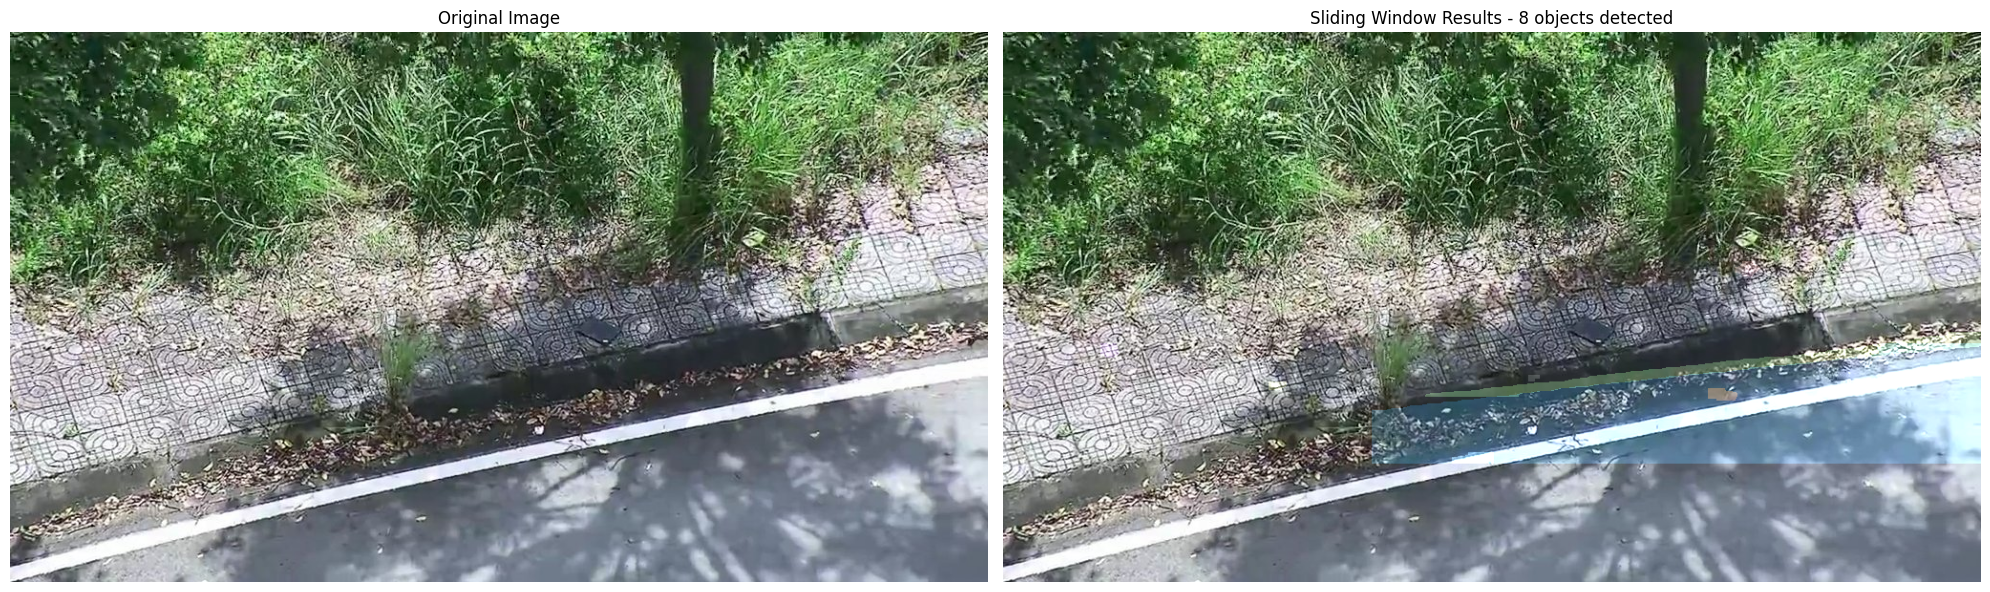


=== Summary ===
Image size: 1024x576
Window size: 1024x1024
Number of windows: 4
Total masks detected: 8
Average confidence: 0.349
Min confidence: 0.211
Max confidence: 0.685


In [ ]:
from ultralytics.models.fastsam import FastSAMPredictor
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import cv2
import os
import tempfile

# Optimized settings for small and blurry objects
# Use larger model for better detection
# Lower confidence threshold to catch faint objects
# Higher resolution for better detail
overrides = dict(conf=0.05, task="segment", mode="predict", model="FastSAM-x.pt", save=False, imgsz=1280)
predictor = FastSAMPredictor(overrides=overrides)

def enhance_image_for_small_objects(img_array):
    """
    Enhance image to improve detection of small and blurry objects
    """
    # Convert to uint8 if needed
    if img_array.dtype != np.uint8:
        img_array = (img_array * 255).astype(np.uint8) if img_array.max() <= 1.0 else img_array.astype(np.uint8)
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for better contrast
    if len(img_array.shape) == 3:
        lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        enhanced = cv2.merge([l, a, b])
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)
    else:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(img_array)
    
    # Apply unsharp masking for sharpening
    gaussian = cv2.GaussianBlur(enhanced, (0, 0), 2.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, gaussian, -0.5, 0)
    
    # Ensure values are in valid range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return sharpened

# Segment everything with sliding window
image_path = "/datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg"

# Load image to get dimensions
img = Image.open(image_path)
img_array = np.array(img)
img_height, img_width = img_array.shape[:2]

print(f"Original image size: {img_width}x{img_height}")

# Enhance image for better small object detection
print("Enhancing image for small object detection...")
img_array_enhanced = enhance_image_for_small_objects(img_array)
print("Image enhancement completed.")

# Sliding window parameters - optimized for small objects
window_size = 1280  # Larger window size for better detail
overlap = 0.6  # Higher overlap (60%) to ensure small objects aren't missed
step_size = int(window_size * (1 - overlap))  # Step size = 40% of window size

print(f"Window size: {window_size}x{window_size}")
print(f"Step size: {step_size} (overlap: {overlap*100}%)")

# Generate sliding windows
all_masks = []
all_boxes = []
all_scores = []

windows = []
for y in range(0, img_height, step_size):
    for x in range(0, img_width, step_size):
        # Calculate window coordinates
        x1 = x
        y1 = y
        x2 = min(x + window_size, img_width)
        y2 = min(y + window_size, img_height)
        
        # Adjust if window is smaller than window_size (at edges)
        if x2 - x1 < window_size:
            x1 = max(0, x2 - window_size)
        if y2 - y1 < window_size:
            y1 = max(0, y2 - window_size)
        
        windows.append((x1, y1, x2, y2))

print(f"Total windows: {len(windows)}")

# Create temporary directory for window images
temp_dir = tempfile.mkdtemp()
temp_files = []

# Process each window
for idx, (x1, y1, x2, y2) in enumerate(windows):
    print(f"Processing window {idx+1}/{len(windows)}: ({x1}, {y1}) -> ({x2}, {y2})")
    
    # Extract window from enhanced image
    window_img = img_array_enhanced[y1:y2, x1:x2]
    
    # Additional enhancement for this specific window if needed
    # Resize to ensure window_size if smaller (for edge cases)
    if window_img.shape[0] < window_size or window_img.shape[1] < window_size:
        # Pad or resize to window_size
        h, w = window_img.shape[:2]
        if h < window_size or w < window_size:
            # Use padding to maintain aspect ratio
            pad_h = max(0, window_size - h)
            pad_w = max(0, window_size - w)
            if len(window_img.shape) == 3:
                window_img = np.pad(window_img, ((0, pad_h), (0, pad_w), (0, 0)), mode='edge')
            else:
                window_img = np.pad(window_img, ((0, pad_h), (0, pad_w)), mode='edge')
    
    # Save temporary window image with high quality
    temp_path = os.path.join(temp_dir, f"window_{idx}.jpg")
    cv2.imwrite(temp_path, cv2.cvtColor(window_img, cv2.COLOR_RGB2BGR), 
                [cv2.IMWRITE_JPEG_QUALITY, 100])
    temp_files.append(temp_path)
    
    # Run prediction on window
    window_results = predictor(temp_path)
    
    # Process results from this window
    for result in window_results:
        if result.masks is not None:
            # Get masks, boxes, and scores
            masks = result.masks.data.cpu().numpy()  # Shape: (N, H, W)
            boxes = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else None
            scores = result.boxes.conf.cpu().numpy() if result.boxes is not None else None
            
            # Adjust coordinates to original image space
            for i, mask in enumerate(masks):
                # Resize mask to window size if needed
                if mask.shape != (y2-y1, x2-x1):
                    mask = cv2.resize(mask.astype(np.uint8), (x2-x1, y2-y1), interpolation=cv2.INTER_NEAREST).astype(bool)
                
                # Create full-size mask for original image
                full_mask = np.zeros((img_height, img_width), dtype=bool)
                full_mask[y1:y2, x1:x2] = mask
                
                all_masks.append(full_mask)
                
                # Adjust box coordinates
                if boxes is not None and i < len(boxes):
                    box = boxes[i].copy()
                    box[0] += x1  # x1
                    box[1] += y1  # y1
                    box[2] += x1  # x2
                    box[3] += y1  # y2
                    all_boxes.append(box)
                
                if scores is not None and i < len(scores):
                    all_scores.append(scores[i])

# Cleanup temporary files
for temp_file in temp_files:
    try:
        if os.path.exists(temp_file):
            os.remove(temp_file)
    except:
        pass
try:
    os.rmdir(temp_dir)
except:
    pass

print(f"\nTotal masks detected across all windows: {len(all_masks)}")

# Remove duplicate/overlapping masks using NMS
def calculate_iou(mask1, mask2):
    """Calculate Intersection over Union (IoU) between two masks"""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection / union

def nms_masks(masks, scores, iou_threshold=0.3):
    """
    Non-Maximum Suppression for masks
    Lower IoU threshold (0.3) to keep more small objects that might overlap slightly
    """
    if len(masks) == 0:
        return [], []
    
    # Sort by score (descending)
    indices = np.argsort(scores)[::-1]
    keep = []
    
    while len(indices) > 0:
        current = indices[0]
        keep.append(current)
        
        if len(indices) == 1:
            break
        
        # Calculate IoU with remaining masks
        current_mask = masks[current]
        ious = []
        for idx in indices[1:]:
            iou = calculate_iou(current_mask, masks[idx])
            ious.append(iou)
        
        # Remove masks with IoU > threshold
        ious = np.array(ious)
        indices = indices[1:][ious < iou_threshold]
    
    return [masks[i] for i in keep], [scores[i] for i in keep]

# Filter out very small masks (likely noise) but keep small objects
# Calculate minimum mask area (e.g., at least 10 pixels)
min_mask_area = 10
original_mask_count = len(all_masks)
filtered_indices = []
for i, mask in enumerate(all_masks):
    if mask.sum() >= min_mask_area:
        filtered_indices.append(i)

if len(filtered_indices) < original_mask_count:
    print(f"Filtering out {original_mask_count - len(filtered_indices)} masks smaller than {min_mask_area} pixels")
    all_masks = [all_masks[i] for i in filtered_indices]
    if len(all_boxes) == original_mask_count:
        all_boxes = [all_boxes[i] for i in filtered_indices]
    if len(all_scores) == original_mask_count:
        all_scores = [all_scores[i] for i in filtered_indices]

# Apply NMS if we have scores (with lower threshold for small objects)
if len(all_masks) > 0:
    if len(all_scores) > 0 and len(all_scores) == len(all_masks):
        print("Applying NMS to remove duplicate masks (IoU threshold: 0.3 for small objects)...")
        filtered_masks, filtered_scores = nms_masks(all_masks, all_scores, iou_threshold=0.3)
        print(f"After NMS: {len(filtered_masks)} unique masks (removed {len(all_masks) - len(filtered_masks)} duplicates)")
        all_masks = filtered_masks
        all_scores = filtered_scores
    else:
        # If no scores, create dummy scores based on mask area
        print("No scores available, using mask area as score for NMS...")
        dummy_scores = [mask.sum() for mask in all_masks]
        filtered_masks, filtered_scores = nms_masks(all_masks, dummy_scores, iou_threshold=0.3)
        print(f"After NMS: {len(filtered_masks)} unique masks (removed {len(all_masks) - len(filtered_masks)} duplicates)")
        all_masks = filtered_masks
        all_scores = filtered_scores if len(all_scores) > 0 else None

# Create combined visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Original image
axes[0].imshow(img_array)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Enhanced image
axes[1].imshow(img_array_enhanced)
axes[1].set_title('Enhanced Image (CLAHE + Sharpening)')
axes[1].axis('off')

# Overlay all masks on original image
overlay = img_array.copy()
if len(all_masks) > 0:
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_masks)))
    
    for i, (mask, color) in enumerate(zip(all_masks, colors)):
        # Create colored mask with border for better visibility
        colored_mask = np.zeros((img_height, img_width, 3), dtype=np.uint8)
        colored_mask[mask] = (np.array(color[:3]) * 255).astype(np.uint8)
        
        # Add border to mask for small objects
        mask_uint8 = mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(colored_mask, contours, -1, (255, 255, 255), 2)
        
        # Blend with original image (higher opacity for small objects)
        overlay = cv2.addWeighted(overlay, 1, colored_mask, 0.5, 0)

axes[2].imshow(overlay)
axes[2].set_title(f'Detection Results - {len(all_masks)} objects detected\n(Enhanced for small/blurry objects)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print summary
print(f"\n=== Summary ===")
print(f"Image size: {img_width}x{img_height}")
print(f"Window size: {window_size}x{window_size}")
print(f"Overlap: {overlap*100}%")
print(f"Number of windows: {len(windows)}")
print(f"Confidence threshold: {overrides['conf']}")
print(f"Model: {overrides['model']}")
print(f"Total masks detected: {len(all_masks)}")

if len(all_masks) > 0:
    mask_areas = [mask.sum() for mask in all_masks]
    print(f"Mask areas - Min: {min(mask_areas)} pixels, Max: {max(mask_areas)} pixels, Avg: {np.mean(mask_areas):.1f} pixels")
    
if all_scores is not None and len(all_scores) > 0:
    print(f"Confidence scores - Min: {np.min(all_scores):.3f}, Max: {np.max(all_scores):.3f}, Avg: {np.mean(all_scores):.3f}")
    
print(f"\nOptimizations for small/blurry objects:")
print(f"  - Image enhancement: CLAHE + Unsharp masking")
print(f"  - Lower confidence threshold: {overrides['conf']}")
print(f"  - Higher resolution: {overrides['imgsz']}")
print(f"  - Higher overlap: {overlap*100}%")
print(f"  - Lower NMS IoU threshold: 0.3")


In [3]:
from ultralytics.models.fastsam import FastSAMPredictor

# Create FastSAMPredictor
overrides = dict(conf=0.25, task="segment", retina_masks=True, mode="predict", model="FastSAM-s.pt", save=True, imgsz=768)
predictor = FastSAMPredictor(overrides=overrides)

# Segment everything
image_path = "/datastore/inseclab/phong/v12-ae/dataset-test/public_test/samples/BlackBox_0/object_images/img_1.jpg"
everything_results = predictor(image_path)


Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.10 GiB. GPU 0 has a total capacity of 79.15 GiB of which 718.56 MiB is free. Process 4027937 has 35.50 GiB memory in use. Process 770583 has 19.74 GiB memory in use. Including non-PyTorch memory, this process has 23.18 GiB memory in use. Of the allocated memory 18.76 GiB is allocated by PyTorch, and 3.92 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [34]:
from ultralytics.models.fastsam import FastSAMPredictor
import torch

# Create FastSAMPredictor
overrides = dict(conf=0.25, task="segment", retina_masks=False, mode="predict", model="FastSAM-s.pt", save=True, imgsz=640)
predictor = FastSAMPredictor(overrides=overrides)

# Segment everything
image_path = "drone-blackbox-13.png"
everything_results = predictor(image_path)

# Lấy kết quả
result = everything_results[0]  # Lấy result đầu tiên

# Lọc top k theo confidence score
k = 10  # Số lượng masks muốn giữ lại

if len(result.boxes) > 0:
    # Lấy confidence scores
    confidences = result.boxes.conf
    
    # Sắp xếp và lấy indices của top k
    top_k_indices = torch.argsort(confidences, descending=True)[:k]
    
    # Lọc boxes, masks và confidences
    result.boxes = result.boxes[top_k_indices]
    if result.masks is not None:
        result.masks = result.masks[top_k_indices]
    
    print(f"Giữ lại {len(top_k_indices)} masks có confidence cao nhất")
    print(f"Top {k} confidence scores: {confidences[top_k_indices]}")


Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 /datastore/inseclab/phong/v12-ae/drone-blackbox-13.png: 640x640 8 objects, 11.3ms
Speed: 7.8ms preprocess, 11.3ms inference, 14.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict64
Giữ lại 8 masks có confidence cao nhất
Top 10 confidence scores: tensor([0.8920, 0.8857, 0.8142, 0.7529, 0.4058, 0.4049, 0.3380, 0.2716], device='cuda:0')


In [15]:
from ultralytics import FastSAM

# Define an inference source
source = "/datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg"

# Create a FastSAM model
model = FastSAM("FastSAM-s.pt")  # or FastSAM-x.pt

# Run inference on an image
everything_results = model(source, device="cuda", retina_masks=False, imgsz=1024, conf=0.05, save=True)



image 1/1 /datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg: 576x1024 39 objects, 16.4ms
Speed: 4.7ms preprocess, 16.4ms inference, 9.5ms postprocess per image at shape (1, 3, 576, 1024)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict45


In [11]:
from ultralytics import SAM

# Load a model
model = SAM("sam2_s.pt")

# Display model information (optional)
model.info()

# Run inference
model("/datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg", show=True, save=True)

Model summary: 339 layers, 46,043,842 parameters, 46,043,842 gradients

image 1/1 /datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg: 1024x1024 1 0, 1 1, 12001.9ms
Speed: 17.1ms preprocess, 12001.9ms inference, 43.5ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict7


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: '0', 1: '1'}
 obb: None
 orig_img: array([[[ 25,  56,  29],
         [ 60,  91,  64],
         [103, 134, 107],
         ...,
         [  0,   9,   0],
         [  0,   8,   0],
         [  0,   7,   0]],
 
        [[ 30,  61,  34],
         [ 50,  81,  54],
         [ 74, 105,  78],
         ...,
         [ 69,  87,  74],
         [ 58,  76,  63],
         [ 56,  74,  61]],
 
        [[ 51,  82,  55],
         [ 34,  65,  38],
         [ 13,  44,  17],
         ...,
         [ 24,  42,  29],
         [  0,  16,   3],
         [  0,  12,   0]],
 
        ...,
 
        [[248, 244, 243],
         [255, 253, 252],
         [255, 255, 254],
         ...,
         [123, 106,  97],
         [123, 106,  97],
         [123, 106,  97]],
 
        [[255, 255, 252],
         [251, 248, 244],
         [238, 235, 

In [ ]:
from ultralytics import SAM

# Load the model
model = SAM("mobile_sam.pt")

# Predict a segment
model.predict(source="lifejacket-1.png", save=True)


image 1/1 /datastore/inseclab/phong/v12-ae/lifejacket-1.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 9992.7ms
Speed: 6.6ms preprocess, 9992.7ms inference, 36.2ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict20


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '10', 11: '11', 12: '12', 13: '13', 14: '14', 15: '15', 16: '16'}
 obb: None
 orig_img: array([[[62, 67, 52],
         [53, 58, 43],
         [52, 57, 42],
         ...,
         [35, 63, 39],
         [25, 54, 29],
         [20, 50, 24]],
 
        [[48, 53, 37],
         [40, 45, 29],
         [40, 46, 29],
         ...,
         [28, 57, 31],
         [21, 51, 25],
         [19, 49, 23]],
 
        [[32, 38, 21],
         [34, 39, 22],
         [30, 36, 19],
         ...,
         [44, 71, 48],
         [34, 62, 37],
         [22, 52, 26]],
 
        ...,
 
        [[20, 36, 33],
         [23, 40, 37],
         [24, 40, 37],
         ...,
         [96, 77, 89],
         [90, 71, 83],
         [91, 71, 83]],
 
        [[

In [20]:
from ultralytics import SAM
help(SAM)

Help on class SAM in module ultralytics.models.sam.model:

class SAM(ultralytics.engine.model.Model)
 |  SAM(model: 'str' = 'sam_b.pt') -> 'None'
 |  
 |  SAM (Segment Anything Model) interface class for real-time image segmentation tasks.
 |  
 |  This class provides an interface to the Segment Anything Model (SAM) from Ultralytics, designed for promptable
 |  segmentation with versatility in image analysis. It supports various prompts such as bounding boxes, points, or
 |  labels, and features zero-shot performance capabilities.
 |  
 |  Attributes:
 |      model (torch.nn.Module): The loaded SAM model.
 |      is_sam2 (bool): Indicates whether the model is SAM2 variant.
 |      task (str): The task type, set to "segment" for SAM models.
 |  
 |  Methods:
 |      predict: Perform segmentation prediction on the given image or video source.
 |      info: Log information about the SAM model.
 |  
 |  Examples:
 |      >>> sam = SAM("sam_b.pt")
 |      >>> results = sam.predict("image.jp

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import SAM

sam = SAM('mobile_sam.pt')

frame = cv2.imread('/datastore/inseclab/phong/v12-ae/dataset/public_test/samples/CardboardBox_0/object_images/img_3.jpg')
results = sam(frame, imgsz=768, device='cuda', verbose=False)[0]

if results.masks is None or results.boxes is None or results.boxes.conf is None:
    print('Không có mask nào từ SAM hoặc không có score.')
else:
    masks = results.masks.data.cpu().numpy()
    scores = results.boxes.conf.detach().cpu().numpy()
    best_idx = int(np.argmax(scores))
    best_conf = float(scores[best_idx])

    if best_idx >= len(masks):
        print('Số lượng mask không khớp với score.')
    else:
        best_mask = masks[best_idx]
        ys, xs = np.where(best_mask)
        if ys.size == 0 or xs.size == 0:
            print('Mask có score cao nhất bị rỗng.')
        else:
            y1, y2 = ys.min(), ys.max()
            x1, x2 = xs.min(), xs.max()
            area = ys.size

            annotated = frame.copy()
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f'score={best_conf:.3f}, area={area}'
            cv2.putText(annotated, label, (x1, max(15, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            plt.figure(figsize=(8, 8))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.title('BBox của mask có score cao nhất')
            plt.axis('off')
            plt.show()


TypeError: 'SAM' object is not subscriptable


Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 /datastore/inseclab/phong/v12-ae/drone-blackbox-13.png: 640x640 5 objects, 6.8ms
Speed: 2.5ms preprocess, 6.8ms inference, 10.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict76
Giữ lại 5 masks có confidence cao nhất
Top 10 confidence scores: [      0.892     0.88565     0.81421      0.7529     0.40577]


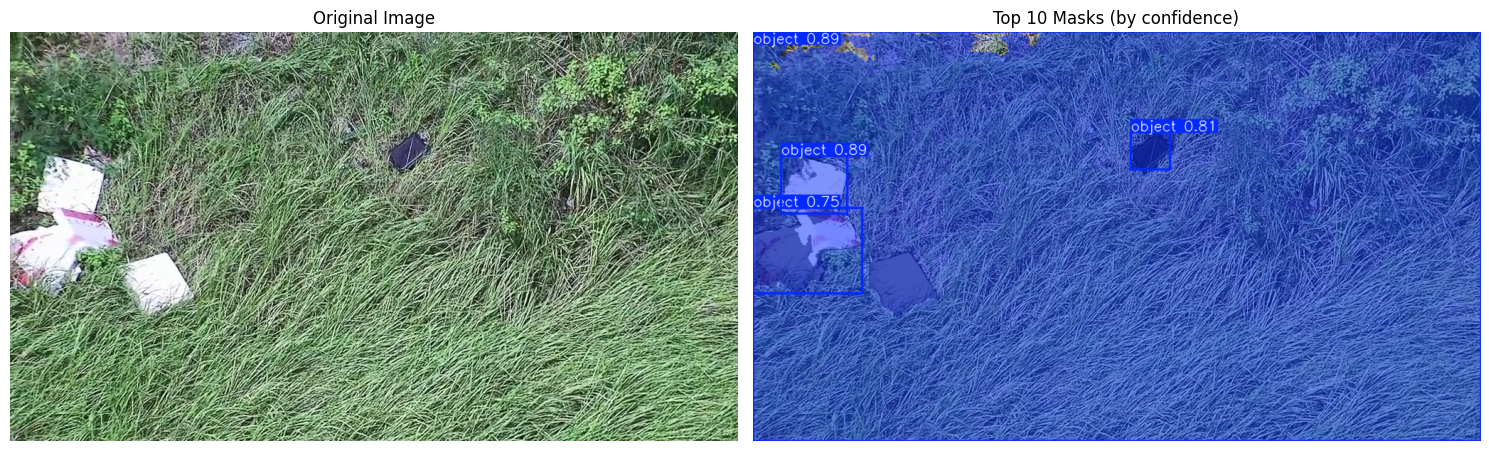


Đã lưu kết quả vào: top_10_masks_comparison.png


In [49]:
from ultralytics.models.fastsam import FastSAMPredictor
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create FastSAMPredictor
overrides = dict(conf=0.25, task="segment", max_det=5, retina_masks=False, mode="predict", model="FastSAM-s.pt", imgsz=640)
predictor = FastSAMPredictor(overrides=overrides)

# Segment everything
image_path = "drone-blackbox-13.png"
everything_results = predictor(image_path)

# Lấy kết quả
result = everything_results[0]

# Lọc top k theo confidence score
k = 10  # Số lượng masks muốn giữ lại

if len(result.boxes) > 0:
    # Lấy confidence scores
    confidences = result.boxes.conf
    
    # Sắp xếp và lấy indices của top k
    top_k_indices = torch.argsort(confidences, descending=True)[:k]
    
    # Tạo result mới với top k
    filtered_result = result[top_k_indices]
    
    print(f"Giữ lại {len(top_k_indices)} masks có confidence cao nhất")
    print(f"Top {k} confidence scores: {confidences[top_k_indices].cpu().numpy()}")
    
    # Đọc ảnh gốc
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot kết quả
    plt.figure(figsize=(15, 10))
    
    # Plot ảnh gốc
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    
    # Plot với top k masks
    plt.subplot(1, 2, 2)
    # Vẽ ảnh với annotations
    annotated_img = filtered_result.plot()
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {k} Masks (by confidence)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'top_{k}_masks_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nĐã lưu kết quả vào: top_{k}_masks_comparison.png")

else:
    print("Không tìm thấy masks nào!")

In [42]:
import gc
gc.collect(); torch.cuda.empty_cache()

In [11]:
import cv2
from ultralytics import SAM

sam = SAM("mobile_sam.pt")

frame = cv2.imread("drone-box-2.png")
results = sam(frame, imgsz=768, device="cuda", save=True)


0: 768x768 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 3113.3ms
Speed: 27.2ms preprocess, 3113.3ms inference, 15.0ms postprocess per image at shape (1, 3, 768, 768)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict34


In [1]:
import cv2
import numpy as np
from ultralytics import SAM

sam = SAM("mobile_sam.pt")

frame = cv2.imread("/datastore/inseclab/phong/v12-ae/drone-5.png")
results = sam(frame, imgsz=768, device="cuda", verbose=False)[0]

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    
    # BƯỚC 1: Lọc masks có đủ pixels trước
    valid_masks = []
    valid_areas = []
    min_pixels = 150
    max_pixels = 3000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        # Bỏ qua mask quá nhỏ hoặc quá lớn, và skip mask rỗng
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    print(f"Sau khi lọc từ {min_pixels} tới {max_pixels} pixels: {len(valid_masks)} masks")
    
    # BƯỚC 2: Lấy top 10 lớn nhất từ những mask đã lọc
    if len(valid_masks) > 10:
        topk_idx = np.argsort(valid_areas)[-10:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 10: {len(valid_masks)} masks")
    
    # Lấy bbox và visualize
    valid_bboxes = []
    for i, mask in enumerate(valid_masks):
        pos = np.where(mask)
        if pos[0].size == 0 or pos[1].size == 0:
            print(f"  Mask {i} bị rỗng sau khi lọc, bỏ qua")
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        print(f"  Mask {i}: {valid_areas[i]} pixels, bbox: [{x1}, {y1}, {x2}, {y2}]")
        valid_bboxes.append([x1, y1, x2, y2])
    
    # Vẽ bbox lên ảnh
    frame_vis = frame.copy()
    for i, bbox in enumerate(valid_bboxes):
        x1, y1, x2, y2 = bbox
        cv2.rectangle(frame_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame_vis, f"{i}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.imwrite("test_filtered_masks.png", frame_vis)
    print(f"\nĐã lưu: test_filtered_masks.png")
    
else:
    print("Không có masks nào!")

Tổng số masks SAM tạo ra: 7
Sau khi lọc từ 150 tới 3000 pixels: 1 masks
Sau khi lấy top 10: 1 masks
  Mask 0: 1932 pixels, bbox: [0, 0, 73, 30]

Đã lưu: test_filtered_masks.png


In [3]:
import cv2
import numpy as np
from ultralytics import SAM
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path

# Load models
sam = SAM("mobile_sam.pt")
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()

# ========================== EMBEDDING ==========================
@torch.no_grad()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return topk

#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    imgs = []
    for p in ref_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        imgs.append(img_resized)
    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# def get_template(ref_paths):
#     imgs = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in ref_paths]
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

# def get_template(ref_paths):
#     imgs = []
#     for p in ref_paths:
#         img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        
#         # Bỏ lề 20% mỗi cạnh
#         h, w = img.shape[:2]
#         margin_h = int(h * 0.4)
#         margin_w = int(w * 0.4)
#         img_cropped = img[margin_h:h-margin_h, margin_w:w-margin_w]
        
#         img_resized = cv2.resize(img_cropped, (224, 224))
#         imgs.append(img_resized)
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

# def get_template(ref_paths, sam=sam):
#     imgs = []
#     for p in ref_paths:
#         img = cv2.imread(str(p))
#         img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
#         # Dùng SAM segment ảnh ref
#         results = sam(img, imgsz=1024, device="cuda", verbose=False)[0]
        
#         if results.masks is not None:
#             masks = results.masks.data.cpu().numpy()

#             best_mask = masks[0]
#             areas = best_mask.sum()
#             # Lấy bbox từ mask
#             pos = np.where(best_mask)
#             if pos[0].size > 0:
#                 y1, y2 = pos[0].min(), pos[0].max()
#                 x1, x2 = pos[1].min(), pos[1].max()
                
#                 # Crop theo bbox
#                 crop = img_rgb[y1:y2+1, x1:x2+1]
#                 crop_resized = cv2.resize(crop, (336, 336))
#                 imgs.append(crop_resized)
#                 print(f"  {p.name}: bbox=[{x1},{y1},{x2},{y2}], area={areas}")
#             else:
#                 # Fallback: crop 20% nếu SAM fail
#                 h, w = img_rgb.shape[:2]
#                 margin_h, margin_w = int(h * 0.2), int(w * 0.2)
#                 crop = img_rgb[margin_h:h-margin_h, margin_w:w-margin_w]
#                 imgs.append(cv2.resize(crop, (224, 224)))
#                 print(f"  {p.name}: SAM fail, dùng crop 20%")
#         else:
#             # Fallback
#             h, w = img_rgb.shape[:2]
#             margin_h, margin_w = int(h * 0.2), int(w * 0.2)
#             crop = img_rgb[margin_h:h-margin_h, margin_w:w-margin_w]
#             imgs.append(cv2.resize(crop, (224, 224)))
#             print(f"  {p.name}: Không có masks, dùng crop 20%")
    
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
# ref_folder = Path("dataset/train/samples/Laptop_0/object_images")
ref_folder = Path("dataset/public_test/samples/LifeJacket_0/object_images")
# ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")

ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("drone-lifejacket-1.png")
results = sam(frame, imgsz=1024, device="cuda", verbose=False)[0]

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    
    # BƯỚC 1: Lọc masks có đủ pixels
    valid_masks = []
    valid_areas = []
    min_pixels = 70
    max_pixels = 1000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_masks)} masks")
    
    # BƯỚC 2: Lấy top 10 lớn nhất
    if len(valid_masks) > 15:
        topk_idx = np.argsort(valid_areas)[-15:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 10: {len(valid_masks)} masks")
    
    # BƯỚC 3: Crop và embed với DINOv2
    crops_rgb = []
    valid_bboxes = []
    
    for mask in valid_masks:
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        crop = frame[y1:y2+1, x1:x2+1]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        
        crops_rgb.append(crop_resized)
        valid_bboxes.append([x1, y1, x2, y2])
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores
        print("\nSimilarity scores:")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            print(f"  Mask {i}: sim={sim.item():.4f}, bbox={bbox}")
        
        # Lấy mask tốt nhất
        best_idx = sims.argmax().item()
        best_sim = sims[best_idx].item()
        best_bbox = valid_bboxes[best_idx]
        
        print(f"\n*** BEST MATCH: Mask {best_idx}, sim={best_sim:.4f}, bbox={best_bbox} ***")
        
        # Visualize - vẽ tất cả bbox màu xanh, best bbox màu đỏ
        frame_vis = frame.copy()
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = bbox
            color = (0, 0, 255) if i == best_idx else (0, 255, 0)  # Đỏ cho best, xanh cho còn lại
            thickness = 3 if i == best_idx else 1
            cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
            cv2.putText(frame_vis, f"{sims[i].item():.2f}", (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\nĐã lưu: test_best_match.png")
        
        # Threshold check
        if best_sim > 0.8:
            print(f"✓ Object DETECTED với confidence {best_sim:.4f}")
        else:
            print(f"✗ Không đủ confident (threshold 0.8)")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks nào!")

Loaded 3 reference images
Tổng số masks SAM tạo ra: 8
Sau khi lọc 70-1000 pixels: 3 masks
Sau khi lấy top 10: 3 masks
Số crops để so khớp: 3

Similarity scores:
  Mask 0: sim=0.8081, bbox=[np.int64(604), np.int64(289), np.int64(640), np.int64(309)]
  Mask 1: sim=0.7761, bbox=[np.int64(728), np.int64(516), np.int64(766), np.int64(549)]
  Mask 2: sim=0.7482, bbox=[np.int64(694), np.int64(510), np.int64(718), np.int64(544)]

*** BEST MATCH: Mask 0, sim=0.8081, bbox=[np.int64(604), np.int64(289), np.int64(640), np.int64(309)] ***

Đã lưu: test_best_match.png
✓ Object DETECTED với confidence 0.8081


In [ ]:
import cv2
import numpy as np
from ultralytics import SAM
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path

# Load models
sam = SAM("mobile_sam.pt")
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return torch.nn.functional.normalize(topk, dim=1)

#========================== GET TEMPLATE ==========================
# def get_template(ref_paths):
#     imgs = []
#     for p in ref_paths:
#         img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
#         img_resized = cv2.resize(img, (224, 224))
#         imgs.append(img_resized)
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

# def get_template(ref_paths):
#     imgs = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in ref_paths]
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

# def get_template(ref_paths):
#     imgs = []
#     for p in ref_paths:
#         img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        
#         # Bỏ lề 20% mỗi cạnh
#         h, w = img.shape[:2]
#         margin_h = int(h * 0.4)
#         margin_w = int(w * 0.4)
#         img_cropped = img[margin_h:h-margin_h, margin_w:w-margin_w]
        
#         img_resized = cv2.resize(img_cropped, (224, 224))
#         imgs.append(img_resized)
#     embs = batch_embed(imgs)
#     template = embs.mean(dim=0)
#     return torch.nn.functional.normalize(template, dim=0)

def get_template(ref_paths, sam_model):
    imgs = []
    for p in ref_paths:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        crop = img_rgb

        results = sam_model(img_rgb, imgsz=640, device="cuda", verbose=False)[0]

        if results.masks is not None and len(results.masks) > 0:
            masks = results.masks.data.cpu().numpy()

            scores = None
            if results.boxes is not None and results.boxes.conf is not None:
                scores = results.boxes.conf.detach().cpu().numpy()
            elif hasattr(results.masks, "scores") and results.masks.scores is not None:
                scores = results.masks.scores.detach().cpu().numpy()

            if scores is not None and len(scores) == len(masks):
                best_idx = int(np.argmax(scores))
            else:
                areas = masks.sum(axis=(1, 2))
                best_idx = int(np.argmax(areas))

            best_mask = masks[best_idx]
            pos = np.where(best_mask)

            if pos[0].size > 100:
                y1, y2 = pos[0].min(), pos[0].max()
                x1, x2 = pos[1].min(), pos[1].max()

                h, w = img_rgb.shape[:2]
                pad_y = max(1, int((y2 - y1 + 1) * 0.05))
                pad_x = max(1, int((x2 - x1 + 1) * 0.05))
                y1 = max(0, y1 - pad_y)
                y2 = min(h - 1, y2 + pad_y)
                x1 = max(0, x1 - pad_x)
                x2 = min(w - 1, x2 + pad_x)

                crop = img_rgb[y1:y2+1, x1:x2+1]
        # Fallback: crop 20% trung tâm khi không có mask dùng được
        if crop.size == 0:
            crop = img_rgb
        if crop is img_rgb:
            h, w = img_rgb.shape[:2]
            margin_h, margin_w = max(1, int(h * 0.2)), max(1, int(w * 0.2))
            crop = img_rgb[margin_h:h-margin_h, margin_w:w-margin_w]
            if crop.size == 0:
                crop = img_rgb

        crop_resized = cv2.resize(crop, (224, 224))
        imgs.append(crop_resized)
    
    if len(imgs) == 0:
        raise ValueError("Không tạo được crop nào từ ảnh tham chiếu.")

    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
# ref_folder = Path("dataset/train/samples/Laptop_0/object_images")
# ref_folder = Path("dataset/public_test/samples/LifeJacket_0/object_images")
# ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")
ref_folder = Path("dataset/public_test/samples/CardboardBox_0/object_images")


ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths,sam)

# Load drone frame
frame = cv2.imread("drone-box-2.png")
results = sam(frame, imgsz=1024, device="cuda", verbose=False)[0]

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    
    # BƯỚC 1: Lọc masks có đủ pixels
    valid_masks = []
    valid_areas = []
    min_pixels = 10
    max_pixels = 4000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_masks)} masks")
    
    # BƯỚC 2: Lấy top 10 lớn nhất
    if len(valid_masks) > 25:
        topk_idx = np.argsort(valid_areas)[-25:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 10: {len(valid_masks)} masks")
    
    # BƯỚC 2.5: Lọc bbox quá lớn (theo kích thước) - trước khi crop và embed
    img_h, img_w = frame.shape[:2]
    max_bbox_width = img_w * 0.2   # Tối đa 10% chiều rộng ảnh
    max_bbox_height = img_h * 0.2  # Tối đa 10% chiều cao ảnh
    max_bbox_area = (img_w * img_h) * 0.05  # Tối đa 10% diện tích ảnh
    
    size_filtered_masks = []
    size_filtered_areas = []
    
    for mask, area in zip(valid_masks, valid_areas):
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        # Loại bỏ bbox quá lớn
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_masks.append(mask)
        size_filtered_areas.append(area)
    
    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_masks)} masks")
    
    # Cập nhật danh sách
    valid_masks = size_filtered_masks
    valid_areas = size_filtered_areas
    
    # BƯỚC 3: Crop và embed với DINOv2
    crops_rgb = []
    valid_bboxes = []
    
    for mask in valid_masks:
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        crop = frame[y1:y2+1, x1:x2+1]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        
        crops_rgb.append(crop_resized)
        valid_bboxes.append([x1, y1, x2, y2])
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores và kích thước
        print("\nSimilarity scores và kích thước:")
        img_h, img_w = frame.shape[:2]
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_area = bbox_w * bbox_h
            mask_area = valid_areas[i]
            print(f"  Mask {i}: sim={sim.item():.4f}, bbox={bbox}, "
                  f"w={bbox_w:.0f}, h={bbox_h:.0f}, bbox_area={bbox_area:.0f}, "
                  f"mask_area={mask_area}, w%={bbox_w/img_w*100:.1f}%, h%={bbox_h/img_h*100:.1f}%")
        
        # Lọc masks có sim > threshold
        threshold = 0.8
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        print(f"\nSau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")
        
        # Xác định best match từ các bbox đã lọc (đã được lọc kích thước ở BƯỚC 2.5)
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            # Lấy mask tốt nhất từ các masks đã lọc
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
            
            print(f"*** BEST MATCH: Mask {best_original_idx}, sim={best_sim:.4f}, bbox={best_bbox} ***")
            print(f"✓ Object DETECTED với confidence {best_sim:.4f}")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")
        
        # Visualize - vẽ tất cả bbox từ valid_bboxes (sau topk), best match màu đỏ
        frame_vis = frame.copy()
        img_h, img_w = frame.shape[:2]
        
        # Kiểm tra length
        print(f"\nKiểm tra: len(valid_bboxes)={len(valid_bboxes)}, len(sims)={len(sims)}")
        assert len(valid_bboxes) == len(sims), f"Length không khớp: valid_bboxes={len(valid_bboxes)}, sims={len(sims)}"
        
        print(f"\nVẽ bbox lên ảnh (tất cả bbox sau topk):")
        drawn_count = 0
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = bbox
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            
            # Kiểm tra bbox có hợp lệ không
            if x1 >= x2 or y1 >= y2:
                print(f"  Mask {i}: Bỏ qua bbox không hợp lệ ({x1},{y1},{x2},{y2})")
                continue
            
            # Kiểm tra bbox có trong ảnh không
            if x1 < 0 or y1 < 0 or x2 > img_w or y2 > img_h:
                print(f"  Mask {i}: Bbox ({x1},{y1},{x2},{y2}) ngoài ảnh ({img_w}x{img_h}), clip lại")
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(img_w, x2)
                y2 = min(img_h, y2)
            
            # Đỏ cho best match, xanh cho còn lại
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)  # Đỏ
                thickness = 5  # Tăng thickness cho best match
                sim_val = best_sim
                print(f"  Mask {i} (BEST): bbox=({x1},{y1},{x2},{y2}), sim={sim_val:.2f}")
            else:
                color = (0, 255, 0)  # Xanh
                thickness = 1
                sim_val = sims[i].item()
            
            try:
                # Vẽ bbox
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
                
                # Vẽ text label (đảm bảo không bị ngoài ảnh)
                text_y = max(y1 - 5, 15)  # Đảm bảo text không bị ngoài ảnh
                cv2.putText(frame_vis, f"{sim_val:.2f}", (x1, text_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                drawn_count += 1
            except Exception as e:
                print(f"  Mask {i}: Lỗi khi vẽ bbox: {e}")
        
        print(f"Đã vẽ {drawn_count}/{len(valid_bboxes)} bbox")
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\nĐã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks nào!")

Loaded 3 reference images
Tổng số masks SAM tạo ra: 37
Sau khi lọc 10-4000 pixels: 26 masks
Sau khi lấy top 10: 25 masks
Sau khi lọc kích thước bbox: 25 masks
Số crops để so khớp: 25

Similarity scores và kích thước:
  Mask 0: sim=0.7291, bbox=[np.int64(161), np.int64(364), np.int64(178), np.int64(399)], w=17, h=35, bbox_area=595, mask_area=389, w%=1.7%, h%=6.1%
  Mask 1: sim=0.7349, bbox=[np.int64(63), np.int64(321), np.int64(97), np.int64(341)], w=34, h=20, bbox_area=680, mask_area=515, w%=3.3%, h%=3.5%
  Mask 2: sim=0.8074, bbox=[np.int64(744), np.int64(489), np.int64(766), np.int64(517)], w=22, h=28, bbox_area=616, mask_area=531, w%=2.1%, h%=4.9%
  Mask 3: sim=0.7369, bbox=[np.int64(210), np.int64(261), np.int64(246), np.int64(281)], w=36, h=20, bbox_area=720, mask_area=600, w%=3.5%, h%=3.5%
  Mask 4: sim=0.7607, bbox=[np.int64(0), np.int64(345), np.int64(21), np.int64(380)], w=21, h=35, bbox_area=735, mask_area=644, w%=2.1%, h%=6.1%
  Mask 5: sim=0.7303, bbox=[np.int64(236), np.in

In [ ]:
import cv2
import numpy as np
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path
from ultralytics.models.fastsam import FastSAMPredictor

# Load models
overrides = dict(
    conf=0.25,  
    task="segment", 
    mode="predict", 
    model="FastSAM-s.pt", 
    imgsz=640,  
    retina_masks=False 
)
sam = FastSAMPredictor(overrides=overrides)

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return torch.nn.functional.normalize(topk, dim=1)

#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    imgs = []
    for p in ref_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        imgs.append(img_resized)
    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")
ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("drone-blackbox-13.png")
img_h, img_w = frame.shape[:2]
print(f"\n{'='*60}")
print(f"Frame gốc: {img_w}x{img_h}")
print(f"{'='*60}")

results = sam(frame)[0]

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    
    # ✅ KIỂM TRA KÍCH THƯỚC MASKS
    mask_h, mask_w = masks[0].shape
    print(f"Kích thước masks: {mask_w}x{mask_h}")
    print(f"⚠️ Masks {'KHÁC' if (mask_w != img_w or mask_h != img_h) else 'GIỐNG'} kích thước frame gốc!")
    
    # ✅ TÍNH TỶ LỆ SCALE
    scale_x = img_w / mask_w
    scale_y = img_h / mask_h
    print(f"Scale factor: x={scale_x:.3f}, y={scale_y:.3f}")
    print(f"{'='*60}\n")
    
    # BƯỚC 1: Lọc masks có đủ pixels
    valid_masks = []
    valid_areas = []
    min_pixels = 10
    max_pixels = 7000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_masks)} masks")
    
    # BƯỚC 2: Lấy top 25
    if len(valid_masks) > 25:
        topk_idx = np.argsort(valid_areas)[-25:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 25: {len(valid_masks)} masks")
    
    # BƯỚC 2.5: Lọc bbox quá lớn (trên mask coordinates)
    max_bbox_width = mask_w * 0.2  # ✅ Dùng mask_w thay vì img_w
    max_bbox_height = mask_h * 0.2  # ✅ Dùng mask_h thay vì img_h
    max_bbox_area = (mask_w * mask_h) * 0.05
    
    size_filtered_masks = []
    size_filtered_areas = []
    
    for mask, area in zip(valid_masks, valid_areas):
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        # Loại bỏ bbox quá lớn
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_masks.append(mask)
        size_filtered_areas.append(area)
    
    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_masks)} masks")
    
    # Cập nhật danh sách
    valid_masks = size_filtered_masks
    valid_areas = size_filtered_areas
    
    # BƯỚC 3: Crop và embed với DINOv2
    crops_rgb = []
    valid_bboxes = []  # ✅ Lưu bbox trong tọa độ ảnh GỐC
    
    for mask in valid_masks:
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        
        # ✅ Lấy bbox trong tọa độ mask
        y1_mask, y2_mask = pos[0].min(), pos[0].max()
        x1_mask, x2_mask = pos[1].min(), pos[1].max()
        
        # ✅ SCALE LÊN TỌA ĐỘ ẢNH GỐC
        x1 = int(x1_mask * scale_x)
        y1 = int(y1_mask * scale_y)
        x2 = int(x2_mask * scale_x)
        y2 = int(y2_mask * scale_y)
        
        # ✅ Đảm bảo trong bounds
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_w - 1, x2)
        y2 = min(img_h - 1, y2)
        
        # Kiểm tra bbox hợp lệ
        if x1 >= x2 or y1 >= y2:
            continue
        
        # Crop từ ảnh GỐC
        crop = frame[y1:y2+1, x1:x2+1]
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue
        
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        
        crops_rgb.append(crop_resized)
        valid_bboxes.append([x1, y1, x2, y2])  # ✅ Lưu tọa độ ảnh gốc
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores
        print(f"\n{'='*60}")
        print("Similarity scores:")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_area = bbox_w * bbox_h
            mask_area = valid_areas[i]
            print(f"  Mask {i}: sim={sim.item():.4f}, bbox=[{x1},{y1},{x2},{y2}], "
                  f"w={bbox_w}, h={bbox_h}, area={bbox_area}, "
                  f"w%={bbox_w/img_w*100:.1f}%, h%={bbox_h/img_h*100:.1f}%")
        
        # Lọc masks có sim > threshold
        threshold = 0.8
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        print(f"\n{'='*60}")
        print(f"Sau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")
        
        # Xác định best match
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
            
            print(f"\n*** BEST MATCH ***")
            print(f"  Mask index: {best_original_idx}")
            print(f"  Similarity: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
            print(f"✅ Object DETECTED")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")
        
        # Visualize
        frame_vis = frame.copy()
        
        print(f"\n{'='*60}")
        print("Vẽ bbox lên ảnh:")
        drawn_count = 0
        
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]
            
            # Kiểm tra bbox hợp lệ
            if x1 >= x2 or y1 >= y2:
                print(f"  Mask {i}: Bỏ qua bbox không hợp lệ ({x1},{y1},{x2},{y2})")
                continue
            
            # Đỏ cho best match, xanh cho còn lại
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)  # Đỏ
                thickness = 3
                sim_val = best_sim
                label = f"BEST: {sim_val:.2f}"
            else:
                color = (0, 255, 0)  # Xanh
                thickness = 1
                sim_val = sims[i].item()
                label = f"{sim_val:.2f}"
            
            try:
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
                text_y = max(y1 - 5, 15)
                cv2.putText(frame_vis, label, (x1, text_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                drawn_count += 1
            except Exception as e:
                print(f"  Mask {i}: Lỗi khi vẽ bbox: {e}")
        
        print(f"Đã vẽ {drawn_count}/{len(valid_bboxes)} bbox")
        print(f"{'='*60}")
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\n✅ Đã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks nào!")

Loaded 3 reference images

Frame gốc: 1024x576

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)


In [2]:
import cv2
import numpy as np
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path
from ultralytics.models.fastsam import FastSAMPredictor

# Load models
overrides = dict(
    conf=0.25,  
    task="segment", 
    mode="predict", 
    model="FastSAM-s.pt", 
    imgsz=640,  
    retina_masks=False 
)
sam = FastSAMPredictor(overrides=overrides)

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return torch.nn.functional.normalize(topk, dim=1)

#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    imgs = []
    for p in ref_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        imgs.append(img_resized)
    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")
ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("drone-blackbox-13.png")
img_h, img_w = frame.shape[:2]
print(f"\n{'='*60}")
print(f"Frame gốc: {img_w}x{img_h}")
print(f"{'='*60}")

results = sam(frame)[0]

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    
    # ✅ KIỂM TRA KÍCH THƯỚC MASKS
    mask_h, mask_w = masks[0].shape
    print(f"Kích thước masks: {mask_w}x{mask_h}")
    print(f"⚠️ Masks {'KHÁC' if (mask_w != img_w or mask_h != img_h) else 'GIỐNG'} kích thước frame gốc!")
    
    # ✅ TÍNH TỶ LỆ SCALE
    scale_x = img_w / mask_w
    scale_y = img_h / mask_h
    print(f"Scale factor: x={scale_x:.3f}, y={scale_y:.3f}")
    print(f"{'='*60}\n")
    
    # BƯỚC 1: Lọc masks có đủ pixels
    valid_masks = []
    valid_areas = []
    min_pixels = 10
    max_pixels = 7000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_masks)} masks")
    
    # BƯỚC 2: Lấy top 25
    if len(valid_masks) > 25:
        topk_idx = np.argsort(valid_areas)[-25:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 25: {len(valid_masks)} masks")
    
    # BƯỚC 2.5: Lọc bbox quá lớn (trên mask coordinates)
    max_bbox_width = mask_w * 0.2  # ✅ Dùng mask_w thay vì img_w
    max_bbox_height = mask_h * 0.2  # ✅ Dùng mask_h thay vì img_h
    max_bbox_area = (mask_w * mask_h) * 0.05
    
    size_filtered_masks = []
    size_filtered_areas = []
    
    for mask, area in zip(valid_masks, valid_areas):
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        # Loại bỏ bbox quá lớn
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_masks.append(mask)
        size_filtered_areas.append(area)
    
    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_masks)} masks")
    
    # Cập nhật danh sách
    valid_masks = size_filtered_masks
    valid_areas = size_filtered_areas
    
    # BƯỚC 3: Crop và embed với DINOv2
    crops_rgb = []
    valid_bboxes = []  # ✅ Lưu bbox trong tọa độ ảnh GỐC
    
    for mask in valid_masks:
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        
        # ✅ Lấy bbox trong tọa độ mask
        y1_mask, y2_mask = pos[0].min(), pos[0].max()
        x1_mask, x2_mask = pos[1].min(), pos[1].max()
        
        # ✅ SCALE LÊN TỌA ĐỘ ẢNH GỐC
        x1 = int(x1_mask * scale_x)
        y1 = int(y1_mask * scale_y)
        x2 = int(x2_mask * scale_x)
        y2 = int(y2_mask * scale_y)
        
        # ✅ Đảm bảo trong bounds
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_w - 1, x2)
        y2 = min(img_h - 1, y2)
        
        # Kiểm tra bbox hợp lệ
        if x1 >= x2 or y1 >= y2:
            continue
        
        # Crop từ ảnh GỐC
        crop = frame[y1:y2+1, x1:x2+1]
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue
        
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        
        crops_rgb.append(crop_resized)
        valid_bboxes.append([x1, y1, x2, y2])  # ✅ Lưu tọa độ ảnh gốc
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores
        print(f"\n{'='*60}")
        print("Similarity scores:")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_area = bbox_w * bbox_h
            mask_area = valid_areas[i]
            print(f"  Mask {i}: sim={sim.item():.4f}, bbox=[{x1},{y1},{x2},{y2}], "
                  f"w={bbox_w}, h={bbox_h}, area={bbox_area}, "
                  f"w%={bbox_w/img_w*100:.1f}%, h%={bbox_h/img_h*100:.1f}%")
        
        # Lọc masks có sim > threshold
        threshold = 0.8
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        print(f"\n{'='*60}")
        print(f"Sau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")
        
        # Xác định best match
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
            
            print(f"\n*** BEST MATCH ***")
            print(f"  Mask index: {best_original_idx}")
            print(f"  Similarity: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
            print(f"✅ Object DETECTED")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")
        
        # Visualize
        frame_vis = frame.copy()
        
        print(f"\n{'='*60}")
        print("Vẽ bbox lên ảnh:")
        drawn_count = 0
        
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]
            
            # Kiểm tra bbox hợp lệ
            if x1 >= x2 or y1 >= y2:
                print(f"  Mask {i}: Bỏ qua bbox không hợp lệ ({x1},{y1},{x2},{y2})")
                continue
            
            # Đỏ cho best match, xanh cho còn lại
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)  # Đỏ
                thickness = 3
                sim_val = best_sim
                label = f"BEST: {sim_val:.2f}"
            else:
                color = (0, 255, 0)  # Xanh
                thickness = 1
                sim_val = sims[i].item()
                label = f"{sim_val:.2f}"
            
            try:
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
                text_y = max(y1 - 5, 15)
                cv2.putText(frame_vis, label, (x1, text_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                drawn_count += 1
            except Exception as e:
                print(f"  Mask {i}: Lỗi khi vẽ bbox: {e}")
        
        print(f"Đã vẽ {drawn_count}/{len(valid_bboxes)} bbox")
        print(f"{'='*60}")
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\n✅ Đã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks nào!")

/home/inseclab/miniconda3/envs/zaic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded 3 reference images

Frame gốc: 1024x576

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
0: 640x640 8 objects, 13.8ms
Speed: 5.7ms preprocess, 13.8ms inference, 1030.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict95
Tổng số masks SAM tạo ra: 8
Kích thước masks: 640x640
⚠️ Masks KHÁC kích thước frame gốc!
Scale factor: x=1.600, y=0.900

Sau khi lọc 10-7000 pixels: 7 masks
Sau khi lấy top 25: 7 masks
Sau khi lọc kích thước bbox: 7 masks
Số crops để so khớp: 7

Similarity scores:
  Mask 0: sim=0.8684, bbox=[163,300,257,350], w=94, h=50, area=4700, w%=9.2%, h%=8.7%
  Mask 1: sim=0.8431, bbox=[41,225,136,269], w=95, h=44, area=4180, w%=9.3%, h%=7.6%
  Mask 2: sim=0.7697, bbox=[534,207,590,238], w=56, h=31, area=1736, w%=5.5%, h%=5.4%
  Mask 3: sim=0.8353, bbox=[3,264,155,335], 

In [3]:
import cv2
import numpy as np
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path
from ultralytics.models.fastsam import FastSAMPredictor

# Load models
overrides = dict(
    conf=0.25,  
    task="segment", 
    mode="predict", 
    model="FastSAM-s.pt", 
    imgsz=640,  
    retina_masks=False 
)
sam = FastSAMPredictor(overrides=overrides)

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return torch.nn.functional.normalize(topk, dim=1)

#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    imgs = []
    for p in ref_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        imgs.append(img_resized)
    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")
ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("drone-blackbox-13.png")
img_h, img_w = frame.shape[:2]
print(f"\n{'='*60}")
print(f"Frame gốc: {img_w}x{img_h}")
print(f"{'='*60}")

results = sam(frame)[0]

if results.masks is not None and results.boxes is not None:
    masks = results.masks.data.cpu().numpy()
    # ✅ DÙNG BOXES.XYXY TRỰC TIẾP - ĐÃ Ở TỌA ĐỘ FRAME GỐC
    boxes_xyxy = results.boxes.xyxy.cpu().numpy()
    confidences = results.boxes.conf.cpu().numpy() if results.boxes.conf is not None else None
    
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    print(f"Tổng số boxes: {len(boxes_xyxy)}")
    
    if confidences is not None:
        print(f"✅ Có confidence scores: min={confidences.min():.3f}, max={confidences.max():.3f}")
    
    # BƯỚC 1: Lọc masks theo pixels (VẪN DÙNG MASKS ĐỂ LỌC)
    valid_mask_indices = []
    valid_areas = []
    valid_confidences = []
    
    min_pixels = 10
    max_pixels = 7000
    
    for idx, mask in enumerate(masks):
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_mask_indices.append(idx)
        valid_areas.append(num_pixels)
        if confidences is not None and idx < len(confidences):
            valid_confidences.append(confidences[idx])
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_mask_indices)} masks")
    
    # BƯỚC 2: Lấy top 25 theo confidence hoặc area
    if len(valid_mask_indices) > 25:
        if valid_confidences and len(valid_confidences) == len(valid_mask_indices):
            topk_idx = np.argsort(valid_confidences)[::-1][:25]
            print(f"✅ Lấy top 25 theo CONFIDENCE")
        else:
            topk_idx = np.argsort(valid_areas)[::-1][:25]
            print(f"⚠️ Lấy top 25 theo AREA")
        
        valid_mask_indices = [valid_mask_indices[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
        if valid_confidences:
            valid_confidences = [valid_confidences[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 25: {len(valid_mask_indices)} masks")
    
    # BƯỚC 2.5: Lọc bbox quá lớn - ✅ DÙNG BOXES_XYXY (TỌA ĐỘ FRAME GỐC)
    max_bbox_width = img_w * 0.2
    max_bbox_height = img_h * 0.2
    max_bbox_area = (img_w * img_h) * 0.05
    
    size_filtered_indices = []
    size_filtered_areas = []
    size_filtered_confidences = []
    
    for i, idx in enumerate(valid_mask_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        # Loại bỏ bbox quá lớn
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_indices.append(idx)
        size_filtered_areas.append(valid_areas[i])
        if valid_confidences and i < len(valid_confidences):
            size_filtered_confidences.append(valid_confidences[i])
    
    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_indices)} masks")
    
    # BƯỚC 3: Crop và embed - ✅ DÙNG BOXES_XYXY
    crops_rgb = []
    valid_bboxes = []
    final_areas = []
    final_confidences = []
    
    for i, idx in enumerate(size_filtered_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox
        
        # Chuyển sang int và clamp
        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(img_w - 1, int(x2))
        y2 = min(img_h - 1, int(y2))
        
        # Kiểm tra bbox hợp lệ
        if x1 >= x2 or y1 >= y2:
            continue
        
        # ✅ CROP TRỰC TIẾP TỪ FRAME
        crop = frame[y1:y2+1, x1:x2+1]
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue
        
        try:
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            crop_resized = cv2.resize(crop_rgb, (224, 224))
            
            crops_rgb.append(crop_resized)
            valid_bboxes.append([x1, y1, x2, y2])
            final_areas.append(size_filtered_areas[i])
            if size_filtered_confidences and i < len(size_filtered_confidences):
                final_confidences.append(size_filtered_confidences[i])
        except Exception as e:
            print(f"  Error cropping bbox {i}: {e}")
            continue
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores
        print(f"\n{'='*60}")
        print("Similarity scores:")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_area = bbox_w * bbox_h
            mask_area = final_areas[i] if i < len(final_areas) else 0
            conf_str = f", conf={final_confidences[i]:.3f}" if final_confidences and i < len(final_confidences) else ""
            
            print(f"  Mask {i}: sim={sim.item():.4f}{conf_str}, bbox=[{x1},{y1},{x2},{y2}], "
                  f"w={bbox_w}, h={bbox_h}, area={bbox_area}, "
                  f"w%={bbox_w/img_w*100:.1f}%, h%={bbox_h/img_h*100:.1f}%")
        
        # Lọc masks có sim > threshold
        threshold = 0.8
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        print(f"\n{'='*60}")
        print(f"Sau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")
        
        # Xác định best match
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
            
            print(f"\n*** BEST MATCH ***")
            print(f"  Mask index: {best_original_idx}")
            print(f"  Similarity: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
            if final_confidences and best_original_idx < len(final_confidences):
                print(f"  Confidence: {final_confidences[best_original_idx]:.4f}")
            print(f"✅ Object DETECTED")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")
        
        # Visualize
        frame_vis = frame.copy()
        
        print(f"\n{'='*60}")
        print("Vẽ bbox lên ảnh:")
        drawn_count = 0
        
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]
            
            # Đỏ cho best match, xanh cho còn lại
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)  # Đỏ
                thickness = 3
                sim_val = best_sim
                label = f"BEST: {sim_val:.2f}"
            else:
                color = (0, 255, 0)  # Xanh
                thickness = 1
                sim_val = sims[i].item()
                label = f"{sim_val:.2f}"
            
            try:
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
                text_y = max(y1 - 5, 15)
                cv2.putText(frame_vis, label, (x1, text_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                drawn_count += 1
            except Exception as e:
                print(f"  Mask {i}: Lỗi khi vẽ bbox: {e}")
        
        print(f"Đã vẽ {drawn_count}/{len(valid_bboxes)} bbox")
        print(f"{'='*60}")
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\n✅ Đã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks hoặc boxes!")

Loaded 3 reference images

Frame gốc: 1024x576

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
0: 640x640 8 objects, 8.1ms
Speed: 3.6ms preprocess, 8.1ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict96
Tổng số masks SAM tạo ra: 8
Tổng số boxes: 8
✅ Có confidence scores: min=0.272, max=0.892
Sau khi lọc 10-7000 pixels: 7 masks
Sau khi lấy top 25: 7 masks
Sau khi lọc kích thước bbox: 4 masks
Số crops để so khớp: 4

Similarity scores:
  Mask 0: sim=0.8573, conf=0.886, bbox=[39,175,132,256], w=93, h=81, area=7533, w%=9.1%, h%=14.1%
  Mask 1: sim=0.8456, conf=0.814, bbox=[531,142,586,194], w=55, h=52, area=2860, w%=5.4%, h%=9.0%
  Mask 2: sim=0.7235, conf=0.338, bbox=[779,233,793,253], w=14, h=20, area=280, w%=1.4%, h%=3.5%
  Mask 3: sim=0.7821, conf=0.272, bbox=[340,0

In [7]:
import cv2
import numpy as np
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path
from ultralytics.models.fastsam import FastSAMPredictor
from transformers import CLIPProcessor, CLIPModel, AutoImageProcessor, ConvNextV2Model

# Load models
overrides = dict(
    conf=0.25,  
    task="segment", 
    mode="predict", 
    model="FastSAM-s.pt", 
    imgsz=640,  
    retina_masks=False 
)
sam = FastSAMPredictor(overrides=overrides)

# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
# clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True).cuda().half()

# mobileclip = CLIPModel.from_pretrained(
#     "apple/mobileclip_s2"  
# ).cuda().half().eval()

# processor = CLIPProcessor.from_pretrained("apple/mobileclip_s2")

# ========================== EMBEDDING ==========================
# @torch.inference_mode()
# def batch_embed(crops):
#     if len(crops) == 0:
#         return torch.empty((0, 512), device="cuda")
#     inputs = processor(images=crops, return_tensors="pt").to("cuda")
#     with torch.autocast("cuda", dtype=torch.float16):
#         # Chỉ dùng vision encoder
#         vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
#         # Lấy hidden states từ vision encoder
#         hidden_states = vision_outputs.last_hidden_state  # [batch, seq_len, hidden_dim]
#         # Bỏ qua CLS token (index 0), lấy các patch tokens
#         patches = hidden_states[:, 1:, :]  # [batch, num_patches, hidden_dim]
#         # Tính norm của mỗi patch để chọn top 16
#         patch_norms = torch.norm(patches, dim=2)  # [batch, num_patches]
#         topk_indices = patch_norms.topk(min(16, patches.size(1)), dim=1).indices  # [batch, 16]
#         # Lấy top 16 patches và average
#         batch_size = patches.size(0)
#         topk_patches = patches[torch.arange(batch_size).unsqueeze(1), topk_indices]  # [batch, 16, hidden_dim]
#         topk = topk_patches.mean(dim=1)  # [batch, hidden_dim]
#     return torch.nn.functional.normalize(topk, dim=1)

# ConvNeXt-V2 Nano: 15M params
processor = AutoImageProcessor.from_pretrained("facebook/convnextv2-nano-22k-224")
convnext = ConvNextV2Model.from_pretrained("facebook/convnextv2-nano-22k-224").cuda().half().eval()

@torch.inference_mode()
def batch_embed(crops, batch_size=8):
    """ConvNeXt-V2 embeddings - 15M params, 640 dim"""
    if len(crops) == 0:
        return torch.empty((0, 640), device="cuda")
    
    all_embs = []
    for i in range(0, len(crops), batch_size):
        batch_crops = crops[i:i+batch_size]
        inputs = processor(images=batch_crops, return_tensors="pt").to("cuda")
        
        with torch.autocast("cuda", dtype=torch.float16):
            outputs = convnext(**inputs)
        
        # Global average pooling
        pooled = outputs.last_hidden_state.mean(dim=[2, 3])
        embs = torch.nn.functional.normalize(pooled, dim=1)
        
        all_embs.append(embs.cpu())
        del inputs, outputs, pooled
    
    result = torch.cat(all_embs, dim=0).cuda()
    del all_embs
    torch.cuda.empty_cache()
    
    return result
#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    imgs = []
    for p in ref_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        imgs.append(img_resized)
    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Load reference images
ref_folder = Path("dataset/public_test/samples/BlackBox_0/object_images")
ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("drone-blackbox-13.png")
img_h, img_w = frame.shape[:2]
print(f"\n{'='*60}")
print(f"Frame gốc: {img_w}x{img_h}")
print(f"{'='*60}")

results = sam(frame)[0]

if results.masks is not None and results.boxes is not None:
    masks = results.masks.data.cpu().numpy()
    # ✅ DÙNG BOXES.XYXY TRỰC TIẾP - ĐÃ Ở TỌA ĐỘ FRAME GỐC
    boxes_xyxy = results.boxes.xyxy.cpu().numpy()
    confidences = results.boxes.conf.cpu().numpy() if results.boxes.conf is not None else None
    
    print(f"Tổng số masks SAM tạo ra: {len(masks)}")
    print(f"Tổng số boxes: {len(boxes_xyxy)}")
    
    if confidences is not None:
        print(f"✅ Có confidence scores: min={confidences.min():.3f}, max={confidences.max():.3f}")
    
    # BƯỚC 1: Lọc masks theo pixels (VẪN DÙNG MASKS ĐỂ LỌC)
    valid_mask_indices = []
    valid_areas = []
    valid_confidences = []
    
    min_pixels = 10
    max_pixels = 7000
    
    for idx, mask in enumerate(masks):
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_mask_indices.append(idx)
        valid_areas.append(num_pixels)
        if confidences is not None and idx < len(confidences):
            valid_confidences.append(confidences[idx])
    
    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_mask_indices)} masks")
    
    # BƯỚC 2: Lấy top 25 theo confidence hoặc area
    if len(valid_mask_indices) > 25:
        if valid_confidences and len(valid_confidences) == len(valid_mask_indices):
            topk_idx = np.argsort(valid_confidences)[::-1][:25]
            print(f"✅ Lấy top 25 theo CONFIDENCE")
        else:
            topk_idx = np.argsort(valid_areas)[::-1][:25]
            print(f"⚠️ Lấy top 25 theo AREA")
        
        valid_mask_indices = [valid_mask_indices[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
        if valid_confidences:
            valid_confidences = [valid_confidences[i] for i in topk_idx]
    
    print(f"Sau khi lấy top 25: {len(valid_mask_indices)} masks")
    
    # BƯỚC 2.5: Lọc bbox quá lớn - ✅ DÙNG BOXES_XYXY (TỌA ĐỘ FRAME GỐC)
    max_bbox_width = img_w * 0.2
    max_bbox_height = img_h * 0.2
    max_bbox_area = (img_w * img_h) * 0.05
    
    size_filtered_indices = []
    size_filtered_areas = []
    size_filtered_confidences = []
    
    for i, idx in enumerate(valid_mask_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        # Loại bỏ bbox quá lớn
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_indices.append(idx)
        size_filtered_areas.append(valid_areas[i])
        if valid_confidences and i < len(valid_confidences):
            size_filtered_confidences.append(valid_confidences[i])
    
    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_indices)} masks")
    
    # BƯỚC 3: Crop và embed - ✅ DÙNG BOXES_XYXY
    crops_rgb = []
    valid_bboxes = []
    final_areas = []
    final_confidences = []
    
    for i, idx in enumerate(size_filtered_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox
        
        # Chuyển sang int và clamp
        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(img_w - 1, int(x2))
        y2 = min(img_h - 1, int(y2))
        
        # Kiểm tra bbox hợp lệ
        if x1 >= x2 or y1 >= y2:
            continue
        
        # ✅ CROP TRỰC TIẾP TỪ FRAME
        crop = frame[y1:y2+1, x1:x2+1]
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue
        
        try:
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            crop_resized = cv2.resize(crop_rgb, (224, 224))
            
            crops_rgb.append(crop_resized)
            valid_bboxes.append([x1, y1, x2, y2])
            final_areas.append(size_filtered_areas[i])
            if size_filtered_confidences and i < len(size_filtered_confidences):
                final_confidences.append(size_filtered_confidences[i])
        except Exception as e:
            print(f"  Error cropping bbox {i}: {e}")
            continue
    
    print(f"Số crops để so khớp: {len(crops_rgb)}")
    
    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        
        # In similarity scores
        print(f"\n{'='*60}")
        print("Similarity scores:")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_area = bbox_w * bbox_h
            mask_area = final_areas[i] if i < len(final_areas) else 0
            conf_str = f", conf={final_confidences[i]:.3f}" if final_confidences and i < len(final_confidences) else ""
            
            print(f"  Mask {i}: sim={sim.item():.4f}{conf_str}, bbox=[{x1},{y1},{x2},{y2}], "
                  f"w={bbox_w}, h={bbox_h}, area={bbox_area}, "
                  f"w%={bbox_w/img_w*100:.1f}%, h%={bbox_h/img_h*100:.1f}%")
        
        # Lọc masks có sim > threshold
        threshold = 0.05
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        print(f"\n{'='*60}")
        print(f"Sau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")
        
        # Xác định best match
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
            
            print(f"\n*** BEST MATCH ***")
            print(f"  Mask index: {best_original_idx}")
            print(f"  Similarity: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
            if final_confidences and best_original_idx < len(final_confidences):
                print(f"  Confidence: {final_confidences[best_original_idx]:.4f}")
            print(f"✅ Object DETECTED")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")
        
        # Visualize
        frame_vis = frame.copy()
        
        print(f"\n{'='*60}")
        print("Vẽ bbox lên ảnh:")
        drawn_count = 0
        
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]
            
            # Đỏ cho best match, xanh cho còn lại
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)  # Đỏ
                thickness = 3
                sim_val = best_sim
                label = f"BEST: {sim_val:.2f}"
            else:
                color = (0, 255, 0)  # Xanh
                thickness = 1
                sim_val = sims[i].item()
                label = f"{sim_val:.2f}"
            
            try:
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
                text_y = max(y1 - 5, 15)
                cv2.putText(frame_vis, label, (x1, text_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                drawn_count += 1
            except Exception as e:
                print(f"  Mask {i}: Lỗi khi vẽ bbox: {e}")
        
        print(f"Đã vẽ {drawn_count}/{len(valid_bboxes)} bbox")
        print(f"{'='*60}")
        
        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\n✅ Đã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks hoặc boxes!")

Loaded 3 reference images

Frame gốc: 1024x576

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
0: 640x640 8 objects, 14.1ms
Speed: 5.8ms preprocess, 14.1ms inference, 4.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict100
Tổng số masks SAM tạo ra: 8
Tổng số boxes: 8
✅ Có confidence scores: min=0.272, max=0.892
Sau khi lọc 10-7000 pixels: 7 masks
Sau khi lấy top 25: 7 masks
Sau khi lọc kích thước bbox: 4 masks
Số crops để so khớp: 4

Similarity scores:
  Mask 0: sim=-0.0240, conf=0.886, bbox=[39,175,132,256], w=93, h=81, area=7533, w%=9.1%, h%=14.1%
  Mask 1: sim=0.0703, conf=0.814, bbox=[531,142,586,194], w=55, h=52, area=2860, w%=5.4%, h%=9.0%
  Mask 2: sim=-0.0270, conf=0.338, bbox=[779,233,793,253], w=14, h=20, area=280, w%=1.4%, h%=3.5%
  Mask 3: sim=0.0066, conf=0.272, bbox=[

In [2]:
pwd

'/datastore/inseclab/phong/v12-ae'

In [4]:
import sys
import os
import importlib.util

# Add mobileclip_repo to path
sys.path.insert(0, '/datastore/inseclab/phong/v12-ae/mobileclip_repo')

# Import reparameterize_model directly from file to avoid loading __init__.py
spec = importlib.util.spec_from_file_location(
    "mobileone", 
    "/datastore/inseclab/phong/v12-ae/mobileclip_repo/mobileclip/modules/common/mobileone.py"
)
mobileone_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mobileone_module)
reparameterize_model = mobileone_module.reparameterize_model

import cv2
import numpy as np
import torch
from pathlib import Path
from ultralytics.models.fastsam import FastSAMPredictor
import open_clip
from PIL import Image

# ========================== LOAD MODELS ==========================
overrides = dict(
    conf=0.1,
    task="segment",
    mode="predict",
    model="FastSAM-s.pt",
    imgsz=640,
    retina_masks=False
)
sam = FastSAMPredictor(overrides=overrides)

# ✅ MobileCLIP-S2: 35.7M params (image encoder only)
model_name = "MobileCLIP-S2"
model_kwargs = {"image_mean": (0, 0, 0), "image_std": (1, 1, 1)}

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name, 
    pretrained='/datastore/inseclab/phong/v12-ae/checkpoints/MobileCLIP2-S2/mobileclip2_s2.pt',  # ✅ Thay đường dẫn checkpoint
    **model_kwargs
)

# ✅ Eval mode + reparameterize
model.eval()
model = reparameterize_model(model)
model = model.cuda().half()

print("✅ Loaded MobileCLIP-S2: 35.7M params (image encoder)")

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops, batch_size=8):
    """MobileCLIP-S2 embeddings - COLOR AWARE"""
    if len(crops) == 0:
        return torch.empty((0, 512), device="cuda")

    all_embs = []

    for i in range(0, len(crops), batch_size):
        batch_crops = crops[i:i+batch_size]
        
        # Convert numpy arrays to PIL Images
        pil_images = [Image.fromarray(crop) for crop in batch_crops]
        
        # Preprocess với MobileCLIP preprocessor
        image_tensors = torch.stack([preprocess(img) for img in pil_images]).cuda()
        
        with torch.amp.autocast('cuda'):
            # Encode images
            image_features = model.encode_image(image_tensors)

        all_embs.append(image_features.cpu())
        del image_tensors, image_features
        torch.cuda.empty_cache()

    result = torch.cat(all_embs, dim=0).cuda()
    del all_embs
    torch.cuda.empty_cache()

    return result

#========================== GET TEMPLATE ==========================
def get_template(ref_paths):
    if len(ref_paths) == 0:
        raise ValueError("❌ No reference images found!")

    imgs = []
    print(f"\n🔍 Loading {len(ref_paths)} reference images...")

    for p in ref_paths:
        img = cv2.imread(str(p))
        if img is None:
            print(f"⚠️ Failed to read {p}")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img_rgb)
        print(f"  ✅ Loaded {p.name}")

    if len(imgs) == 0:
        raise ValueError("❌ No images loaded!")

    print(f"\n🧠 Embedding {len(imgs)} images with MobileCLIP-S2...")
    embs = batch_embed(imgs)
    print(f"✅ Embeddings shape: {embs.shape}")
    print(f"✅ Embeddings range: [{embs.min():.4f}, {embs.max():.4f}]")

    # Create template (mean of embeddings)
    template = embs.mean(dim=0)

    # Test self-similarity
    sims = torch.nn.functional.cosine_similarity(embs, template.unsqueeze(0), dim=1)
    print(f"✅ Self-similarity: {sims.mean().item():.4f} (target: ~0.90)")

    return template

# ========================== MAIN ==========================
ref_folder = Path("dataset/public_test/samples/LifeJacket_0/object_images")

if not ref_folder.exists():
    print(f"❌ Folder not found: {ref_folder}")
    raise FileNotFoundError()

ref_paths = sorted(ref_folder.glob("*.jpg"))
if len(ref_paths) == 0:
    ref_paths = sorted(ref_folder.glob("*.png"))

print(f"Found {len(ref_paths)} reference images")

if len(ref_paths) == 0:
    raise ValueError("No reference images!")

template = get_template(ref_paths)

# Load drone frame
frame = cv2.imread("lifejacket-1.png")
if frame is None:
    raise ValueError("Failed to load frame!")

img_h, img_w = frame.shape[:2]
print(f"\n{'='*60}")
print(f"Frame gốc: {img_w}x{img_h}")
print(f"{'='*60}")

results = sam(frame)[0]

if results.masks is not None and results.boxes is not None:
    masks = results.masks.data.cpu().numpy()
    boxes_xyxy = results.boxes.xyxy.cpu().numpy()
    confidences = results.boxes.conf.cpu().numpy() if results.boxes.conf is not None else None

    print(f"Tổng số masks SAM tạo ra: {len(masks)}")

    # BƯỚC 1: Lọc masks theo pixels
    valid_mask_indices = []
    valid_areas = []
    valid_confidences = []

    min_pixels = 0
    max_pixels = 3000

    for idx, mask in enumerate(masks):
        pos = np.where(mask)
        num_pixels = len(pos[0])

        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue

        valid_mask_indices.append(idx)
        valid_areas.append(num_pixels)
        if confidences is not None and idx < len(confidences):
            valid_confidences.append(confidences[idx])

    print(f"Sau khi lọc {min_pixels}-{max_pixels} pixels: {len(valid_mask_indices)} masks")

    # BƯỚC 2: Lấy top 25
    if len(valid_mask_indices) > 25:
        if valid_confidences and len(valid_confidences) == len(valid_mask_indices):
            topk_idx = np.argsort(valid_confidences)[::-1][:25]
            print(f"✅ Lấy top 25 theo CONFIDENCE")
        else:
            topk_idx = np.argsort(valid_areas)[::-1][:25]
            print(f"⚠️ Lấy top 25 theo AREA")

        valid_mask_indices = [valid_mask_indices[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
        if valid_confidences:
            valid_confidences = [valid_confidences[i] for i in topk_idx]

    print(f"Sau khi lấy top 25: {len(valid_mask_indices)} masks")

    # BƯỚC 2.5: Lọc bbox quá lớn
    max_bbox_width = img_w * 0.2
    max_bbox_height = img_h * 0.15
    max_bbox_area = (img_w * img_h) * 0.03

    size_filtered_indices = []
    size_filtered_areas = []
    size_filtered_confidences = []

    for i, idx in enumerate(valid_mask_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox

        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h

        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue

        size_filtered_indices.append(idx)
        size_filtered_areas.append(valid_areas[i])
        if valid_confidences and i < len(valid_confidences):
            size_filtered_confidences.append(valid_confidences[i])

    print(f"Sau khi lọc kích thước bbox: {len(size_filtered_indices)} masks")

    # BƯỚC 3: Crop và embed
    crops_rgb = []
    valid_bboxes = []
    final_areas = []
    final_confidences = []

    for i, idx in enumerate(size_filtered_indices):
        bbox = boxes_xyxy[idx]
        x1, y1, x2, y2 = bbox

        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(img_w - 1, int(x2))
        y2 = min(img_h - 1, int(y2))

        if x1 >= x2 or y1 >= y2:
            continue

        crop = frame[y1:y2+1, x1:x2+1]
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue

        try:
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

            crops_rgb.append(crop_rgb)
            valid_bboxes.append([x1, y1, x2, y2])
            final_areas.append(size_filtered_areas[i])
            if size_filtered_confidences and i < len(size_filtered_confidences):
                final_confidences.append(size_filtered_confidences[i])
        except Exception as e:
            continue

    print(f"Số crops để so khớp: {len(crops_rgb)}")

    # BƯỚC 4: So khớp với template
    if len(crops_rgb) > 0:
        embs = batch_embed(crops_rgb)
        sims = torch.nn.functional.cosine_similarity(embs, template.unsqueeze(0), dim=1)

        print(f"\n{'='*60}")
        print("Similarity scores (MobileCLIP-S2):")
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            x1, y1, x2, y2 = bbox
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            conf_str = f", conf={final_confidences[i]:.3f}" if final_confidences and i < len(final_confidences) else ""

            print(f"  Mask {i}: sim={sim.item():.4f}{conf_str}, bbox=[{x1},{y1},{x2},{y2}], "
                  f"w={bbox_w}, h={bbox_h}")

        # ✅ Threshold cho MobileCLIP (khác ConvNeXt)
        threshold = 0.4
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []

        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)

        print(f"\n{'='*60}")
        print(f"Sau khi lọc sim > {threshold}: {len(filtered_bboxes)} masks")

        best_original_idx = None
        best_sim = 0.0
        best_bbox = None

        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]

            print(f"\n*** BEST MATCH ***")
            print(f"  Mask index: {best_original_idx}")
            print(f"  Similarity: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
            if final_confidences and best_original_idx < len(final_confidences):
                print(f"  Confidence: {final_confidences[best_original_idx]:.4f}")
            print(f"✅ Object DETECTED")
        else:
            print(f"\n✗ Không có mask nào có sim > {threshold}")
            print(f"  Best sim: {sims.max().item():.4f}")

        # Visualize
        frame_vis = frame.copy()

        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]

            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)
                thickness = 3
                sim_val = best_sim
                label = f"BEST: {sim_val:.2f}"
            else:
                color = (0, 255, 0)
                thickness = 1
                sim_val = sims[i].item()
                label = f"{sim_val:.2f}"

            cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
            text_y = max(y1 - 5, 15)
            cv2.putText(frame_vis, label, (x1, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        cv2.imwrite("test_best_match.png", frame_vis)
        print(f"\n✅ Đã lưu: test_best_match.png")
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks hoặc boxes!")

/home/inseclab/miniconda3/envs/zaic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Loaded MobileCLIP-S2: 35.7M params (image encoder)
Found 3 reference images

🔍 Loading 3 reference images...
  ✅ Loaded img_1.jpg
  ✅ Loaded img_2.jpg
  ✅ Loaded img_3.jpg

🧠 Embedding 3 images with MobileCLIP-S2...
✅ Embeddings shape: torch.Size([3, 512])
✅ Embeddings range: [-0.3049, 0.2908]
✅ Self-similarity: 0.9751 (target: ~0.90)

Frame gốc: 1024x576

Ultralytics 8.3.228 🚀 Python-3.11.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
0: 640x640 32 objects, 6.0ms
Speed: 3.0ms preprocess, 6.0ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict133
Tổng số masks SAM tạo ra: 32
Sau khi lọc 0-3000 pixels: 30 masks
✅ Lấy top 25 theo CONFIDENCE
Sau khi lấy top 25: 25 masks
Sau khi lọc kích thước bbox: 23 masks
Số crops để so khớp: 23

Similarity scores (MobileCLIP-S2):
  Mask 0: sim=0.2590, conf=0.791, bb

In [4]:
# Test embedding 1 ảnh
test_img = cv2.imread(str(ref_paths[0]))
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(test_img_rgb)
img_tensor = preprocess(pil_img).unsqueeze(0).cuda()

with torch.amp.autocast('cuda'):
    features = model.encode_image(img_tensor)

print(f"Features shape: {features.shape}")
print(f"Features range: [{features.min():.4f}, {features.max():.4f}]")
print(f"Features norm: {features.norm(dim=1)}")  # ← Kiểm tra xem đã normalized chưa

Features shape: torch.Size([1, 512])
Features range: [-0.1835, 0.2842]
Features norm: tensor([0.9565], device='cuda:0', dtype=torch.float16, grad_fn=<LinalgVectorNormBackward0>)


In [19]:
import cv2
import numpy as np
from ultralytics import SAM
from transformers import AutoImageProcessor, AutoModel
import torch
from pathlib import Path
import time

# Load models
print("Loading models...")
t0 = time.time()
sam = SAM("mobile_sam.pt")
t_sam_load = time.time() - t0

t0 = time.time()
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").cuda().eval()
t_dino_load = time.time() - t0

print(f"Model loading time: SAM={t_sam_load:.3f}s, DINOv2={t_dino_load:.3f}s")

# ========================== EMBEDDING ==========================
@torch.inference_mode()
def batch_embed(crops):
    if len(crops) == 0:
        return torch.empty((0, 384), device="cuda")
    inputs = processor(images=crops, return_tensors="pt").to("cuda")
    with torch.autocast("cuda", dtype=torch.float16):
        out = dinov2(**inputs)
    patches = out.last_hidden_state[:, 1:]
    topk = patches.topk(16, dim=1).values.mean(dim=1)
    return torch.nn.functional.normalize(topk, dim=1)

#========================== GET TEMPLATE ==========================
def get_template(ref_paths, sam_model):
    imgs = []
    for p in ref_paths:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        crop = img_rgb

        results = sam_model(img_rgb, imgsz=640, device="cuda", verbose=False)[0]

        if results.masks is not None and len(results.masks) > 0:
            masks = results.masks.data.cpu().numpy()

            scores = None
            if results.boxes is not None and results.boxes.conf is not None:
                scores = results.boxes.conf.detach().cpu().numpy()
            elif hasattr(results.masks, "scores") and results.masks.scores is not None:
                scores = results.masks.scores.detach().cpu().numpy()

            if scores is not None and len(scores) == len(masks):
                best_idx = int(np.argmax(scores))
            else:
                areas = masks.sum(axis=(1, 2))
                best_idx = int(np.argmax(areas))

            best_mask = masks[best_idx]
            pos = np.where(best_mask)

            if pos[0].size > 100:
                y1, y2 = pos[0].min(), pos[0].max()
                x1, x2 = pos[1].min(), pos[1].max()

                h, w = img_rgb.shape[:2]
                pad_y = max(1, int((y2 - y1 + 1) * 0.05))
                pad_x = max(1, int((x2 - x1 + 1) * 0.05))
                y1 = max(0, y1 - pad_y)
                y2 = min(h - 1, y2 + pad_y)
                x1 = max(0, x1 - pad_x)
                x2 = min(w - 1, x2 + pad_x)

                crop = img_rgb[y1:y2+1, x1:x2+1]
        
        if crop.size == 0:
            crop = img_rgb
        if crop is img_rgb:
            h, w = img_rgb.shape[:2]
            margin_h, margin_w = max(1, int(h * 0.2)), max(1, int(w * 0.2))
            crop = img_rgb[margin_h:h-margin_h, margin_w:w-margin_w]
            if crop.size == 0:
                crop = img_rgb

        crop_resized = cv2.resize(crop, (224, 224))
        imgs.append(crop_resized)
    
    if len(imgs) == 0:
        raise ValueError("Không tạo được crop nào từ ảnh tham chiếu.")

    embs = batch_embed(imgs)
    template = embs.mean(dim=0)
    return torch.nn.functional.normalize(template, dim=0)

# ========================== MAIN ==========================
# Timing dictionary
timing = {}

# Load reference images
ref_folder = Path("dataset/public_test/samples/CardboardBox_0/object_images")
ref_paths = sorted(ref_folder.glob("*.jpg"))
print(f"Loaded {len(ref_paths)} reference images")

# Get template embedding
t0 = time.time()
template = get_template(ref_paths, sam)
timing['template_creation'] = time.time() - t0
print(f"Template creation time: {timing['template_creation']:.3f}s")

# Load drone frame
frame = cv2.imread("drone-box-2.png")
img_h, img_w = frame.shape[:2]
print(f"Frame size: {img_w}x{img_h}")

# Warmup GPU (optional but recommended for accurate timing)
print("\nWarmup GPU...")
_ = sam(frame, imgsz=1024, device="cuda", verbose=False)
torch.cuda.synchronize()

# ===================== INFERENCE TIMING =====================
print("\n" + "="*50)
print("INFERENCE TIMING")
print("="*50)

# STEP 1: SAM segmentation
torch.cuda.synchronize()
t0 = time.time()
results = sam(frame, imgsz=768, device="cuda", verbose=False)[0]
torch.cuda.synchronize()
timing['sam_inference'] = time.time() - t0

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    print(f"\n[SAM] {len(masks)} masks generated in {timing['sam_inference']*1000:.1f}ms")
    
    # STEP 2: Filter masks by pixel count
    t0 = time.time()
    valid_masks = []
    valid_areas = []
    min_pixels = 10
    max_pixels = 4000
    
    for mask in masks:
        pos = np.where(mask)
        num_pixels = len(pos[0])
        
        if num_pixels < min_pixels or num_pixels > max_pixels:
            continue
        
        valid_masks.append(mask)
        valid_areas.append(num_pixels)
    
    # Top 25 largest
    if len(valid_masks) > 25:
        topk_idx = np.argsort(valid_areas)[-25:]
        valid_masks = [valid_masks[i] for i in topk_idx]
        valid_areas = [valid_areas[i] for i in topk_idx]
    
    # Filter by bbox size
    max_bbox_width = img_w * 0.2
    max_bbox_height = img_h * 0.2
    max_bbox_area = (img_w * img_h) * 0.05
    
    size_filtered_masks = []
    size_filtered_areas = []
    
    for mask, area in zip(valid_masks, valid_areas):
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        bbox_area = bbox_w * bbox_h
        
        if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
            continue
        
        size_filtered_masks.append(mask)
        size_filtered_areas.append(area)
    
    valid_masks = size_filtered_masks
    valid_areas = size_filtered_areas
    timing['mask_filtering'] = time.time() - t0
    print(f"[Filter] {len(valid_masks)} masks after filtering in {timing['mask_filtering']*1000:.1f}ms")
    
    # STEP 3: Crop regions
    t0 = time.time()
    crops_rgb = []
    valid_bboxes = []
    
    for mask in valid_masks:
        pos = np.where(mask)
        if pos[0].size == 0:
            continue
        y1, y2 = pos[0].min(), pos[0].max()
        x1, x2 = pos[1].min(), pos[1].max()
        
        crop = frame[y1:y2+1, x1:x2+1]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        
        crops_rgb.append(crop_resized)
        valid_bboxes.append([x1, y1, x2, y2])
    timing['cropping'] = time.time() - t0
    print(f"[Crop] {len(crops_rgb)} crops prepared in {timing['cropping']*1000:.1f}ms")
    
    # STEP 4: DINOv2 embedding and matching
    if len(crops_rgb) > 0:
        torch.cuda.synchronize()
        t0 = time.time()
        embs = batch_embed(crops_rgb)
        torch.cuda.synchronize()
        timing['dino_embedding'] = time.time() - t0
        
        t0 = time.time()
        sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)
        torch.cuda.synchronize()
        timing['similarity'] = time.time() - t0
        
        print(f"[DINOv2] Embedding {len(crops_rgb)} crops in {timing['dino_embedding']*1000:.1f}ms")
        print(f"[Similarity] Computed in {timing['similarity']*1000:.3f}ms")
        
        # STEP 5: Filtering and finding best match
        t0 = time.time()
        threshold = 0.8
        filtered_indices = []
        filtered_sims = []
        filtered_bboxes = []
        
        for i, (sim, bbox) in enumerate(zip(sims, valid_bboxes)):
            if sim.item() > threshold:
                filtered_indices.append(i)
                filtered_sims.append(sim.item())
                filtered_bboxes.append(bbox)
        
        best_original_idx = None
        best_sim = 0.0
        best_bbox = None
        
        if len(filtered_bboxes) > 0:
            best_filtered_idx = np.argmax(filtered_sims)
            best_original_idx = filtered_indices[best_filtered_idx]
            best_sim = filtered_sims[best_filtered_idx]
            best_bbox = filtered_bboxes[best_filtered_idx]
        timing['post_processing'] = time.time() - t0
        print(f"[Post] Best match found in {timing['post_processing']*1000:.3f}ms")
        
        # ===================== SUMMARY =====================
        print("\n" + "="*50)
        print("TIMING SUMMARY")
        print("="*50)
        
        # Total inference time (không bao gồm visualization)
        total_inference = (timing['sam_inference'] + 
                         timing['mask_filtering'] + 
                         timing['cropping'] + 
                         timing['dino_embedding'] + 
                         timing['similarity'] + 
                         timing['post_processing'])
        
        print(f"\n{'Step':<25} {'Time (ms)':<12} {'%':<8}")
        print("-"*45)
        print(f"{'SAM Inference':<25} {timing['sam_inference']*1000:<12.1f} {timing['sam_inference']/total_inference*100:<8.1f}")
        print(f"{'Mask Filtering':<25} {timing['mask_filtering']*1000:<12.1f} {timing['mask_filtering']/total_inference*100:<8.1f}")
        print(f"{'Cropping':<25} {timing['cropping']*1000:<12.1f} {timing['cropping']/total_inference*100:<8.1f}")
        print(f"{'DINOv2 Embedding':<25} {timing['dino_embedding']*1000:<12.1f} {timing['dino_embedding']/total_inference*100:<8.1f}")
        print(f"{'Similarity Compute':<25} {timing['similarity']*1000:<12.3f} {timing['similarity']/total_inference*100:<8.1f}")
        print(f"{'Post Processing':<25} {timing['post_processing']*1000:<12.3f} {timing['post_processing']/total_inference*100:<8.1f}")
        print("-"*45)
        print(f"{'TOTAL INFERENCE':<25} {total_inference*1000:<12.1f} {'100.0':<8}")
        print(f"\n{'FPS (theoretical)':<25} {1/total_inference:<12.1f}")
        
        # Detection result
        print("\n" + "="*50)
        print("DETECTION RESULT")
        print("="*50)
        if best_bbox is not None:
            print(f"✓ Object DETECTED")
            print(f"  Confidence: {best_sim:.4f}")
            print(f"  BBox: {best_bbox}")
        else:
            print(f"✗ No detection (best sim: {sims.max().item():.4f})")
        
        # Visualization
        t0 = time.time()
        frame_vis = frame.copy()
        
        for i, bbox in enumerate(valid_bboxes):
            x1, y1, x2, y2 = [int(v) for v in bbox]
            
            if x1 >= x2 or y1 >= y2:
                continue
            
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_w, x2)
            y2 = min(img_h, y2)
            
            if best_original_idx is not None and i == best_original_idx:
                color = (0, 0, 255)
                thickness = 5
                sim_val = best_sim
            else:
                color = (0, 255, 0)
                thickness = 1
                sim_val = sims[i].item()
            
            cv2.rectangle(frame_vis, (x1, y1), (x2, y2), color, thickness)
            text_y = max(y1 - 5, 15)
            cv2.putText(frame_vis, f"{sim_val:.2f}", (x1, text_y), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        cv2.imwrite("test_best_match.png", frame_vis)
        timing['visualization'] = time.time() - t0
        print(f"\nVisualization saved in {timing['visualization']*1000:.1f}ms")
        
    else:
        print("Không có crops nào để so khớp!")
else:
    print("Không có masks nào!")

Loading models...
Model loading time: SAM=0.332s, DINOv2=2.908s
Loaded 3 reference images
Template creation time: 5.740s
Frame size: 1024x576

Warmup GPU...

INFERENCE TIMING

[SAM] 38 masks generated in 1963.3ms
[Filter] 25 masks after filtering in 149.2ms
[Crop] 25 crops prepared in 74.6ms
[DINOv2] Embedding 25 crops in 147.9ms
[Similarity] Computed in 0.274ms
[Post] Best match found in 0.628ms

TIMING SUMMARY

Step                      Time (ms)    %       
---------------------------------------------
SAM Inference             1963.3       84.0    
Mask Filtering            149.2        6.4     
Cropping                  74.6         3.2     
DINOv2 Embedding          147.9        6.3     
Similarity Compute        0.274        0.0     
Post Processing           0.628        0.0     
---------------------------------------------
TOTAL INFERENCE           2335.9       100.0   

FPS (theoretical)         0.4         

DETECTION RESULT
✓ Object DETECTED
  Confidence: 0.8072
  BBox: [n


image 1/1 /datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg: 384x640 (no detections), 96.9ms
Speed: 4.3ms preprocess, 96.9ms inference, 29.0ms postprocess per image at shape (1, 3, 384, 640)


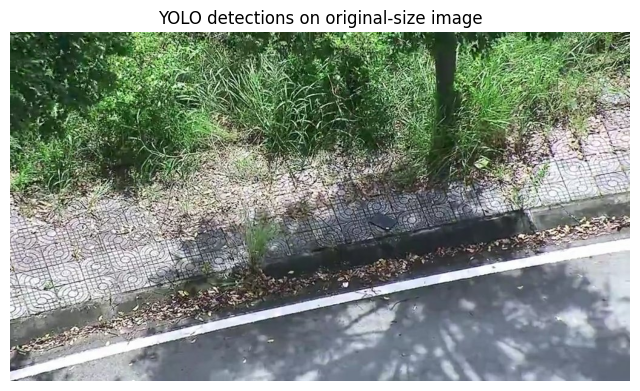

In [14]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8n pretrained COCO
model = YOLO("yolov8x.pt")

# Input image path
image_path = "/datastore/inseclab/phong/v12-ae/drone_video.mp4_snapshot_01.47_[2025-11-18_15.21.19].jpg"

# Run detection but keep annotations in-memory so we can draw on the original size image
results = model.predict(image_path, save=False)

# Original image (keeps exact W x H)
orig_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
annotated = orig_img.copy()

# Extract bounding boxes
r = results[0]  # chỉ có 1 ảnh
boxes = r.boxes  # danh sách bbox

# In kết quả + vẽ bbox trên ảnh gốc
for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()   # tọa độ bbox (theo ảnh gốc)
    conf = float(box.conf[0])               # độ tự tin
    cls_id = int(box.cls[0])                # ID class
    cls_name = model.names[cls_id]          # tên class

    print(f"Box: {x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f} | conf={conf:.2f} | class={cls_name}")

    cv2.rectangle(annotated, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    label = f"{cls_name} {conf:.2f}"
    cv2.putText(annotated, label, (int(x1), max(15, int(y1) - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(8, 6))
plt.imshow(annotated)
plt.title("YOLO detections on original-size image")
plt.axis("off")
plt.show()


In [37]:
from ultralytics import YOLOE

# Initialize a YOLOE model
model = YOLOE("yoloe-v8l-seg-pf.pt")

# Run prediction. No prompts required.
results = model.predict("drone-1.png", save=True)

# Show results
results[0].show()


image 1/1 /datastore/inseclab/phong/v12-ae/drone-1.png: 384x640 1 backyard, 1 habitat, 1 japanese garden, 1 plantation, 2 streams, 1 swimming hole, 1 water surface, 1 weed, 141.6ms
Speed: 6.8ms preprocess, 141.6ms inference, 70.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /datastore/inseclab/phong/v12-ae/runs/segment/predict16


✓ Successfully imported SAM2ImagePredictor


/home/inseclab/miniconda3/envs/zaic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


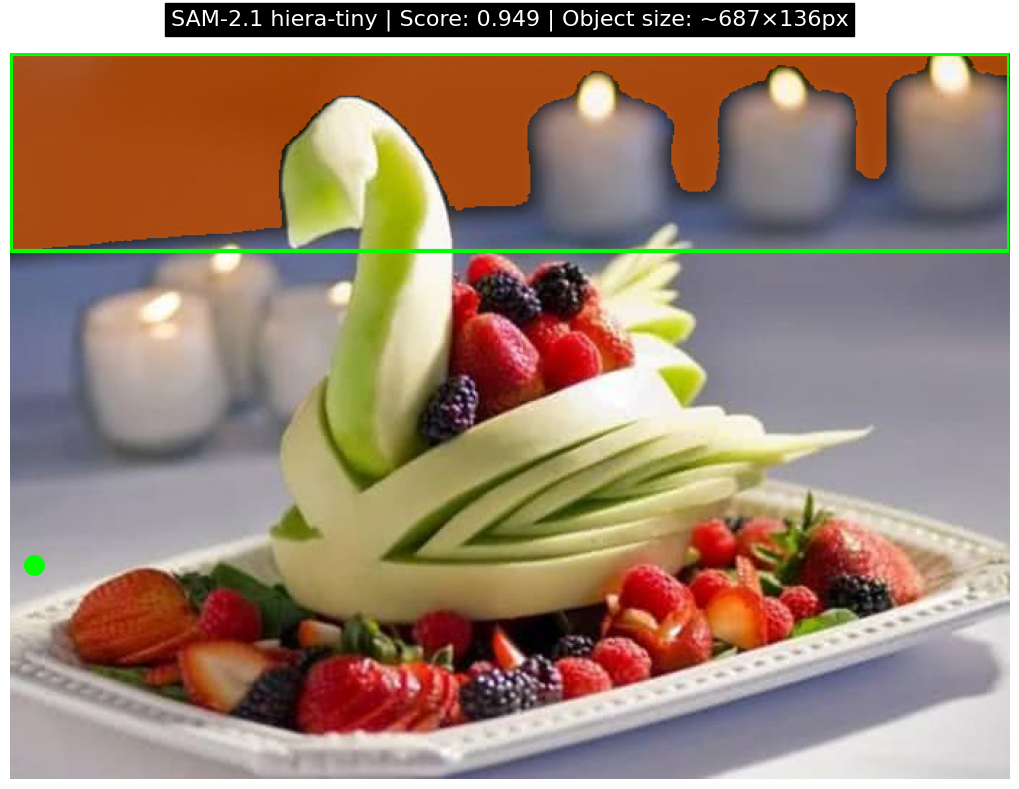

In [1]:
# demo_sam2_segment.py
# Chạy ngay: python demo_sam2_segment.py

import sys
import os

# Add segment-anything-2 to path if needed
segment_anything_path = "/datastore/inseclab/phong/v12-ae/segment-anything-2"
if segment_anything_path not in sys.path:
    sys.path.insert(0, segment_anything_path)

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Try importing sam2
try:
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    print("✓ Successfully imported SAM2ImagePredictor")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print("Attempting to install sam2...")
    import subprocess
    result = subprocess.run([sys.executable, "-m", "pip", "install", "-e", segment_anything_path], 
                          capture_output=True, text=True)
    if result.returncode == 0:
        print("✓ Installation successful, retrying import...")
        from sam2.sam2_image_predictor import SAM2ImagePredictor
        print("✓ Successfully imported SAM2ImagePredictor after installation")
    else:
        raise ImportError(f"Failed to install sam2: {result.stderr}")


# Load SAM-2.1 tiny siêu nhanh từ HuggingFace (tự động tải lần đầu)
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-tiny")
predictor.model.cuda()
predictor.model.eval()

# Đổi đường dẫn ảnh này thành bất kỳ frame nào trong drone video của bạn
# (object càng nhỏ mờ càng tốt để thấy sức mạnh thật sự)
image_path = "diatraicay.jpg"      # <-- Thay bằng ảnh của bạn ở đây
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image_rgb)
    
    # Chỉ cần click 1 điểm gần object (hoặc để tự động tìm điểm tốt nhất)
    # Bạn thử cả 2 cách đều được
    
    # Cách 1: Tự động tìm điểm tốt nhất bằng similarity với chính nó (luôn chuẩn)
    embedding = predictor.get_image_embedding()
    sim = torch.nn.functional.cosine_similarity(embedding, embedding, dim=1).squeeze()
    y, x = torch.argmax(sim).item() // 64, torch.argmax(sim).item() % 64
    input_point = np.array([[x * 16, y * 16]])   # upscale về ảnh gốc
    input_label = np.array([1])

    # Cách 2: Click tay (uncomment 2 dòng dưới nếu muốn click)
    # plt.imshow(image_rgb)
    # pts = plt.ginput(1); input_point = np.array([[pts[0][0], pts[0][1]]]); input_label = np.array([1]); plt.close()

    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True
    )

# Vẽ kết quả đẹp lung linh
best_mask = masks[np.argmax(scores)]

# Đảm bảo mask là boolean và cùng kích thước với ảnh gốc
if best_mask.dtype != bool:
    best_mask = best_mask > 0.5
if best_mask.shape != image_rgb.shape[:2]:
    best_mask = cv2.resize(best_mask.astype(np.uint8), (image_rgb.shape[1], image_rgb.shape[0]), interpolation=cv2.INTER_NEAREST).astype(bool)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis('off')

# Vẽ mask đẹp
mask_color = np.array([255, 100, 0, 150], dtype=np.uint8)  # cam trong suốt
masked_image = image_rgb.copy()
masked_image[best_mask] = (masked_image[best_mask] * 0.4 + mask_color[:3] * 0.6).astype(np.uint8)

plt.imshow(masked_image)

# Vẽ điểm prompt + bbox
y_x, x_y = input_point[0]
plt.plot(x_y, y_x, 'o', markersize=12, color='lime', markeredgewidth=3)

# Vẽ bbox
ys, xs = np.where(best_mask)
if len(xs) > 0:
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    plt.plot([x1, x2, x2, x2, x1, x1], [y1, y1, y2, y2, y2, y1], color='lime', lw=3)

plt.title(f"SAM-2.1 hiera-tiny | Score: {scores.max():.3f} | Object size: ~{x2-x1}×{y2-y1}px", 
          fontsize=16, color='white', backgroundcolor='black', pad=20)
plt.tight_layout()
plt.show()

In [12]:
!pip install open_clip

ERROR: Could not find a version that satisfies the requirement open_clip (from versions: none)
ERROR: No matching distribution found for open_clip


In [21]:
# ========================== IMPORTS ==========================
import os
import gc
import cv2
import torch
import numpy as np
from pathlib import Path
import json
from tqdm import tqdm
from ultralytics.models.fastsam import FastSAMPredictor
from ultralytics import SAM
import open_clip
from PIL import Image


# ========================== LOAD MODELS ==========================
print("Đang load FastSAM + MobileCLIP-S2...")

# FastSAM
overrides = dict(
    conf=0.25,  
    task="segment", 
    mode="predict", 
    model="FastSAM-s.pt", 
    imgsz=640,  
    retina_masks=False,
    max_det=50 
)

sam_template = SAM("mobile_sam.pt")
sam = FastSAMPredictor(overrides=overrides)

from transformers import AutoImageProcessor, ConvNextV2Model
import torch

# ConvNeXt-V2 Nano: 15M params
processor = AutoImageProcessor.from_pretrained("facebook/convnextv2-nano-22k-224")
convnext = ConvNextV2Model.from_pretrained("facebook/convnextv2-nano-22k-224").cuda().half().eval()

@torch.inference_mode()
def batch_embed(crops, batch_size=8):
    """ConvNeXt-V2 embeddings - 15M params, 640 dim"""
    if len(crops) == 0:
        return torch.empty((0, 640), device="cuda")
    
    all_embs = []
    for i in range(0, len(crops), batch_size):
        batch_crops = crops[i:i+batch_size]
        inputs = processor(images=batch_crops, return_tensors="pt").to("cuda")
        
        with torch.autocast("cuda", dtype=torch.float16):
            outputs = convnext(**inputs)
        
        # Global average pooling
        pooled = outputs.last_hidden_state.mean(dim=[2, 3])
        embs = torch.nn.functional.normalize(pooled, dim=1)
        
        all_embs.append(embs.cpu())
        del inputs, outputs, pooled
    
    result = torch.cat(all_embs, dim=0).cuda()
    del all_embs
    torch.cuda.empty_cache()
    
    return result


# ========================== REFERENCE TEMPLATE ==========================
def get_template(ref_paths, sam_model):
    print(f"\n🔍 Processing {len(ref_paths)} reference images...")
    imgs = []
    
    for idx, p in enumerate(ref_paths):
        print(f"  📸 Image {idx+1}/{len(ref_paths)}: {p.name}")
        
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            print(f"    ⚠️  Failed to read image")
            continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        print(f"    📐 Original size: {img_rgb.shape[1]}x{img_rgb.shape[0]}")
        
        crop = img_rgb

        results = sam_model(img_rgb)
        result = results[0] if len(results) > 0 else None

        if result is not None and result.masks is not None and len(result.masks) > 0:
            masks = result.masks.data.cpu().numpy()
            print(f"    🎭 Found {len(masks)} masks")

            scores = None
            if result.boxes is not None and result.boxes.conf is not None:
                scores = result.boxes.conf.detach().cpu().numpy()
            elif hasattr(result.masks, "scores") and result.masks.scores is not None:
                scores = result.masks.scores.detach().cpu().numpy()

            if scores is not None and len(scores) == len(masks):
                best_idx = int(np.argmax(scores))
                print(f"    ⭐ Best mask: #{best_idx} (score: {scores[best_idx]:.3f})")
            else:
                areas = masks.sum(axis=(1, 2))
                best_idx = int(np.argmax(areas))
                print(f"    ⭐ Best mask: #{best_idx} (largest area: {int(areas[best_idx])} pixels)")

            best_mask = masks[best_idx]
            pos = np.where(best_mask)

            if pos[0].size > 100:
                y1, y2 = pos[0].min(), pos[0].max()
                x1, x2 = pos[1].min(), pos[1].max()

                h, w = img_rgb.shape[:2]
                pad_y = max(1, int((y2 - y1 + 1) * 0.05))
                pad_x = max(1, int((x2 - x1 + 1) * 0.05))
                y1 = max(0, y1 - pad_y)
                y2 = min(h - 1, y2 + pad_y)
                x1 = max(0, x1 - pad_x)
                x2 = min(w - 1, x2 + pad_x)

                crop = img_rgb[y1:y2+1, x1:x2+1]
                print(f"    ✂️  Cropped to: {crop.shape[1]}x{crop.shape[0]} (bbox: [{x1},{y1},{x2},{y2}])")

            del masks, scores
        else:
            print(f"    ⚠️  No masks found, using fallback crop")

        if crop.size == 0:
            crop = img_rgb
        if crop is img_rgb:
            h, w = img_rgb.shape[:2]
            margin_h, margin_w = max(1, int(h * 0.2)), max(1, int(w * 0.2))
            crop = img_rgb[margin_h:h-margin_h, margin_w:w-margin_w]
            if crop.size == 0:
                crop = img_rgb
            print(f"    ✂️  Center crop: {crop.shape[1]}x{crop.shape[0]}")

        # ✅ Không cần resize về 224 - MobileCLIP preprocess sẽ tự làm
        imgs.append(crop)
        print(f"    ✅ Added crop")
        
        del results, result, img_bgr, img_rgb, crop
        torch.cuda.empty_cache()

    if len(imgs) == 0:
        raise ValueError("❌ Không tạo được crop nào từ ảnh tham chiếu.")

    print(f"\n🧠 Embedding {len(imgs)} crops...")
    embs = batch_embed(imgs)
    print(f"✅ Embeddings shape: {embs.shape}")
    
    template = embs.mean(dim=0)
    result = torch.nn.functional.normalize(template, dim=0)
    
    print(f"✅ Template created! Shape: {result.shape}, Norm: {torch.norm(result).item():.4f}")
    
    del embs, template, imgs
    torch.cuda.empty_cache()
    
    return result

# ========================== HELPER FUNCTIONS ==========================
def bbox_center(bbox):
    return ((bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2)

def bbox_distance(bbox1, bbox2):
    c1 = bbox_center(bbox1)
    c2 = bbox_center(bbox2)
    return np.sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2)

def bbox_iou(bbox1, bbox2):
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])

    if x2 <= x1 or y2 <= y1:
        return 0.0

    inter = (x2 - x1) * (y2 - y1)
    area1 = (bbox1[2] - bbox1[0]) * (bbox1[3] - bbox1[1])
    area2 = (bbox2[2] - bbox2[0]) * (bbox2[3] - bbox2[1])
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0.0

# ========================== MAIN PROCESS ==========================
@torch.inference_mode()
def process_video(folder: Path):
    video_path = folder / "drone_video_test_1.mp4"
    refs = sorted((folder / "object_images").glob("*.jpg"))
    video_id = folder.name

    print(f"\n{'='*60}")
    print(f"📹 Video: {video_id}")
    print(f"{'='*60}")

    template = get_template(refs, sam_template)

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"\n🎬 Processing video: {total_frames} frames")

    detections = []
    skip_counter = 0

    last_bbox = None
    frames_since_last_det = 0
    max_frames_lost = 30

    pbar = tqdm(total=total_frames, desc=video_id, leave=False)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx = int(pbar.n)
        img_h, img_w = frame.shape[:2]

        should_detect = (skip_counter % 2 == 0)

        if should_detect:
            torch.cuda.empty_cache()
            
            results = sam(frame)[0]

            if results.masks is None or len(results.masks) == 0:
                frames_since_last_det += 1
                if frames_since_last_det > max_frames_lost:
                    last_bbox = None
                
                del results
                torch.cuda.empty_cache()
                
                pbar.update(1)
                skip_counter += 1
                continue

            # ✅ LẤY BOXES.XYXY
            if results.boxes is not None and results.boxes.xyxy is not None:
                boxes_xyxy = results.boxes.xyxy.cpu().numpy()
                has_boxes = True
            else:
                boxes_xyxy = None
                has_boxes = False
            
            masks = results.masks.data.cpu().numpy()
            
            if results.boxes is not None and results.boxes.conf is not None:
                confidences = results.boxes.conf.cpu().numpy()
            else:
                confidences = None

            del results
            torch.cuda.empty_cache()

            # Lọc masks theo pixel
            min_pixels = 70
            max_pixels = 4000
            valid_mask_indices = []
            valid_areas = []
            valid_confidences = []

            for idx, mask in enumerate(masks):
                pos = np.where(mask)
                num_pixels = len(pos[0])
                if min_pixels <= num_pixels <= max_pixels:
                    valid_mask_indices.append(idx)
                    valid_areas.append(num_pixels)
                    if confidences is not None and idx < len(confidences):
                        valid_confidences.append(confidences[idx])

            # Lấy top 24
            if len(valid_mask_indices) > 24:
                if valid_confidences and len(valid_confidences) == len(valid_mask_indices):
                    topk_idx = np.argsort(valid_confidences)[::-1][:24]
                    valid_mask_indices = [valid_mask_indices[i] for i in topk_idx]
                    valid_areas = [valid_areas[i] for i in topk_idx]
                    valid_confidences = [valid_confidences[i] for i in topk_idx]
                else:
                    topk_idx = np.argsort(valid_areas)[::-1][:24]
                    valid_mask_indices = [valid_mask_indices[i] for i in topk_idx]
                    valid_areas = [valid_areas[i] for i in topk_idx]

            del masks, confidences

            # Lọc bbox quá lớn
            max_bbox_width = img_w * 0.2
            max_bbox_height = img_h * 0.2
            max_bbox_area = (img_w * img_h) * 0.05

            size_filtered_indices = []
            size_filtered_areas = []
            size_filtered_confidences = []

            for i, idx in enumerate(valid_mask_indices):
                if has_boxes and idx < len(boxes_xyxy):
                    bbox = boxes_xyxy[idx]
                    x1, y1, x2, y2 = bbox
                else:
                    continue
                
                bbox_w = x2 - x1
                bbox_h = y2 - y1
                bbox_area = bbox_w * bbox_h

                if bbox_w > max_bbox_width or bbox_h > max_bbox_height or bbox_area > max_bbox_area:
                    continue

                size_filtered_indices.append(idx)
                size_filtered_areas.append(valid_areas[i])
                if valid_confidences and i < len(valid_confidences):
                    size_filtered_confidences.append(valid_confidences[i])

            del valid_mask_indices, valid_areas, valid_confidences

            # ✅ Crop và embed
            crops_rgb = []
            bboxes = []
            
            for idx in size_filtered_indices:
                if has_boxes and idx < len(boxes_xyxy):
                    bbox = boxes_xyxy[idx]
                    x1, y1, x2, y2 = bbox
                    
                    x1 = max(0, int(x1))
                    y1 = max(0, int(y1))
                    x2 = min(img_w - 1, int(x2))
                    y2 = min(img_h - 1, int(y2))
                    
                    if x1 >= x2 or y1 >= y2:
                        continue

                    crop = frame[y1:y2+1, x1:x2+1]
                    
                    if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
                        continue
                    
                    try:
                        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                        # ✅ Không cần resize - MobileCLIP preprocess sẽ tự làm
                        crops_rgb.append(crop_rgb)
                        bboxes.append([x1, y1, x2, y2])
                    except Exception as e:
                        continue

            del size_filtered_indices, size_filtered_areas, size_filtered_confidences

            if crops_rgb:
                embs = batch_embed(crops_rgb)
                sims = torch.nn.functional.cosine_similarity(embs, template, dim=1)

                sims_cpu = sims.cpu().numpy()
                del embs, sims
                torch.cuda.empty_cache()

                sim_threshold = 0.78
                candidates = []
                for idx in range(len(sims_cpu)):
                    if sims_cpu[idx] > sim_threshold:
                        candidates.append({
                            'idx': idx,
                            'sim': float(sims_cpu[idx]),
                            'bbox': bboxes[idx]
                        })

                del sims_cpu, crops_rgb, bboxes

                if candidates:
                    best_candidate = None

                    if last_bbox is None:
                        best_candidate = max(candidates, key=lambda x: x['sim'])
                    else:
                        max_velocity = 50 * (frames_since_last_det + 1)
                        max_distance = min(max_velocity, 200)

                        nearby_candidates = []
                        for cand in candidates:
                            dist = bbox_distance(last_bbox, cand['bbox'])
                            if dist <= max_distance:
                                proximity_score = 1 - (dist / max_distance)
                                combined_score = 0.6 * cand['sim'] + 0.4 * proximity_score
                                cand['combined_score'] = combined_score
                                cand['distance'] = dist
                                nearby_candidates.append(cand)

                        if nearby_candidates:
                            best_candidate = max(nearby_candidates, key=lambda x: x['combined_score'])
                        else:
                            high_sim_candidates = [c for c in candidates if c['sim'] > 0.85]
                            if high_sim_candidates:
                                best_candidate = max(high_sim_candidates, key=lambda x: x['sim'])
                                last_bbox = None

                    if best_candidate:
                        x1, y1, x2, y2 = best_candidate['bbox']
                        detections.append({
                            "frame": frame_idx,
                            "x1": int(x1),
                            "y1": int(y1),
                            "x2": int(x2),
                            "y2": int(y2)
                        })
                        last_bbox = best_candidate['bbox']
                        frames_since_last_det = 0
                    else:
                        frames_since_last_det += 1
                else:
                    frames_since_last_det += 1
            else:
                frames_since_last_det += 1

            if frames_since_last_det > max_frames_lost:
                last_bbox = None

        skip_counter += 1
        pbar.update(1)
        
        if frame_idx % 30 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    cap.release()
    pbar.close()
    
    print(f"✅ Detected {len(detections)} bboxes before interpolation")
    
    gc.collect()
    torch.cuda.empty_cache()

    # INTERPOLATION
    if len(detections) > 1:
        full_dets = []
        max_gap = 5
        max_interp_distance = 100

        sorted_dets = sorted(detections, key=lambda x: x["frame"])

        for i in range(len(sorted_dets)):
            det = sorted_dets[i]
            full_dets.append(det)

            if i < len(sorted_dets) - 1:
                next_det = sorted_dets[i + 1]
                gap = next_det["frame"] - det["frame"]

                bbox1 = [det["x1"], det["y1"], det["x2"], det["y2"]]
                bbox2 = [next_det["x1"], next_det["y1"], next_det["x2"], next_det["y2"]]
                distance = bbox_distance(bbox1, bbox2)

                if 1 < gap <= max_gap and distance <= max_interp_distance:
                    for f in range(det["frame"] + 1, next_det["frame"]):
                        alpha = (f - det["frame"]) / gap
                        bbox = {
                            "frame": f,
                            "x1": int(det["x1"] * (1-alpha) + next_det["x1"] * alpha),
                            "y1": int(det["y1"] * (1-alpha) + next_det["y1"] * alpha),
                            "x2": int(det["x2"] * (1-alpha) + next_det["x2"] * alpha),
                            "y2": int(det["y2"] * (1-alpha) + next_det["y2"] * alpha),
                        }
                        full_dets.append(bbox)

        detections = sorted(full_dets, key=lambda x: x["frame"])
        print(f"✅ After interpolation: {len(detections)} bboxes")

    if len(detections) > 0:
        final_output_detections = [{"bboxes": detections}]
    else:
        final_output_detections = []

    return {"video_id": video_id, "detections": final_output_detections}

# ========================== MAIN ==========================
if __name__ == "__main__":
    DATA_DIR = "/content/drive/MyDrive/ZaloAI/public_test/samples"
    OUTPUT_FILE = "/content/submission.json"

    results = []
    data_path = Path(DATA_DIR)

    if not data_path.exists():
        print(f"❌ Lỗi: Không tìm thấy thư mục {DATA_DIR}")
    else:
        folders = sorted([f for f in data_path.iterdir() if (f / "drone_video_test_1.mp4").exists()])
        print(f"\n🎯 Tìm thấy {len(folders)} video để xử lý\n")

        for folder in folders:
            try:
                res = process_video(folder)
                results.append(res)
            except Exception as e:
                print(f"❌ Error processing {folder.name}: {e}")
                import traceback
                traceback.print_exc()
                results.append({"video_id": folder.name, "detections": []})
            
            gc.collect()
            torch.cuda.empty_cache()

        json.dump(results, open(OUTPUT_FILE, "w"), indent=2)
        print(f"\n✅ Hoàn tất! Output: {OUTPUT_FILE}")

        import shutil
        drive_output = f"{DATA_DIR}/submission.json"
        shutil.copy(OUTPUT_FILE, drive_output)
        print(f"✅ Đã copy kết quả vào: {drive_output}")

Đang load FastSAM + MobileCLIP-S2...
❌ Lỗi: Không tìm thấy thư mục /content/drive/MyDrive/ZaloAI/public_test/samples
